# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 08     |  |
| :-------------|:-------------|
| Sybren Kuijlaars | 6540414 |
| Alesja Zorina| 6575129|
| Daan d'Engelbronner| 6537812 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Sybren', 'Alesja','Daan']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie | voor 11:30 |
| testen meetopstelling | voor 12:00 |
| groep aanwezig 1| 11:00-12:30 |
| groep aanwezig 2| 13:30-17:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| ong 14:30-15:00 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

### kalibratie-opstelling groep 08
<img src="Calibreer_opstelling.jpeg" width="400">

[0.03444092 0.73670131]


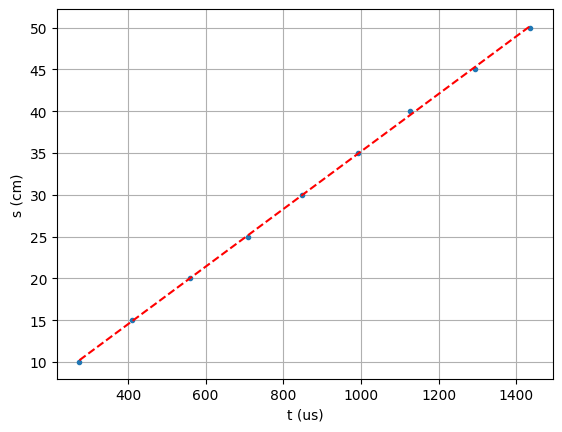

In [3]:
from scipy.optimize import curve_fit

arduino_meting = np.array([275,410,560,708,848,991,1126,1293,1436])
afstand = np.array([10,15,20,25,30,35,40,45,50])

def Afstand(x,a,b):
    return a*x + b

var, cov = curve_fit(Afstand,arduino_meting,afstand)

x_fit = np.linspace(np.min(arduino_meting),np.max(arduino_meting),10000)
y_fit = Afstand(x_fit,*var)

print(var)

plt.figure()
plt.plot(arduino_meting, afstand, ".")
plt.plot(x_fit,y_fit,'r--')
plt.xlabel("t (us)")
plt.ylabel("s (cm)")
plt.grid(True)
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  44.50
1   0  30   0  20  44.50
2  40   0  30   0  47.46
3  30   0  20   0  45.30


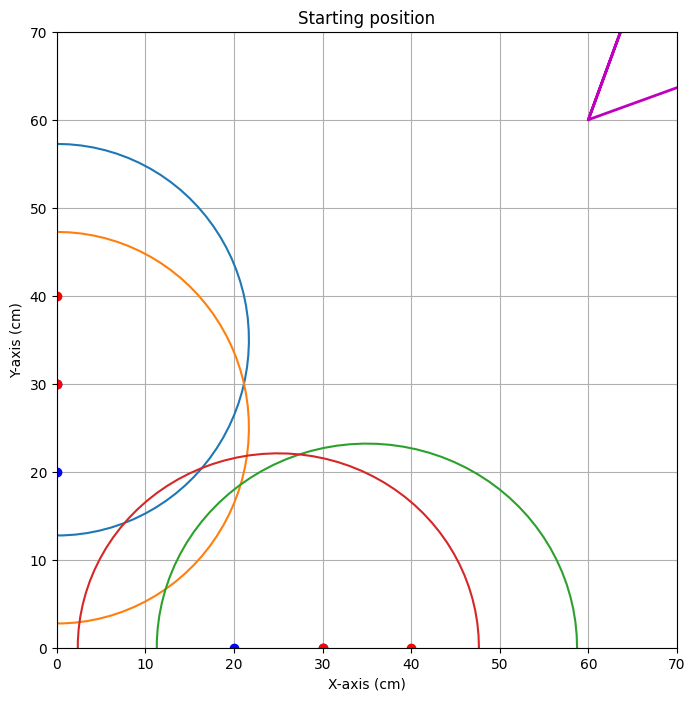


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=96.515


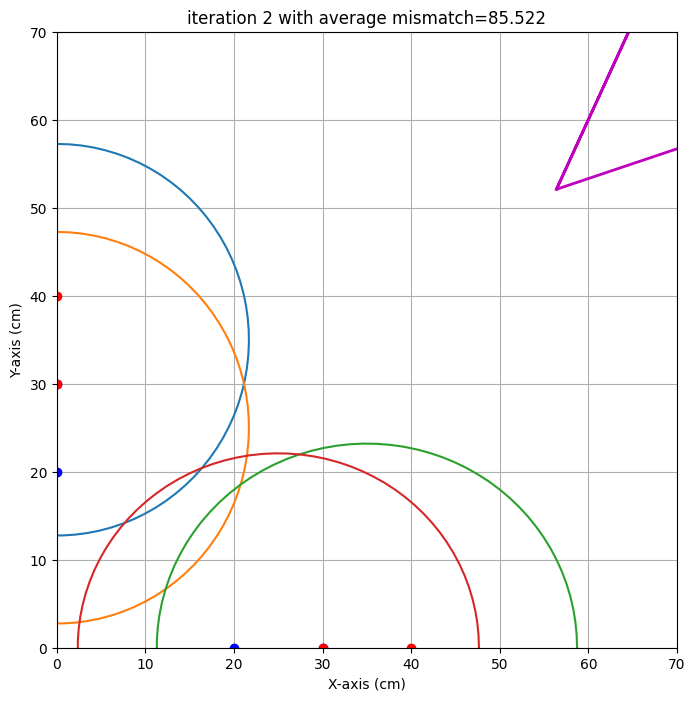

end iteration 2 with average mismatch=85.522


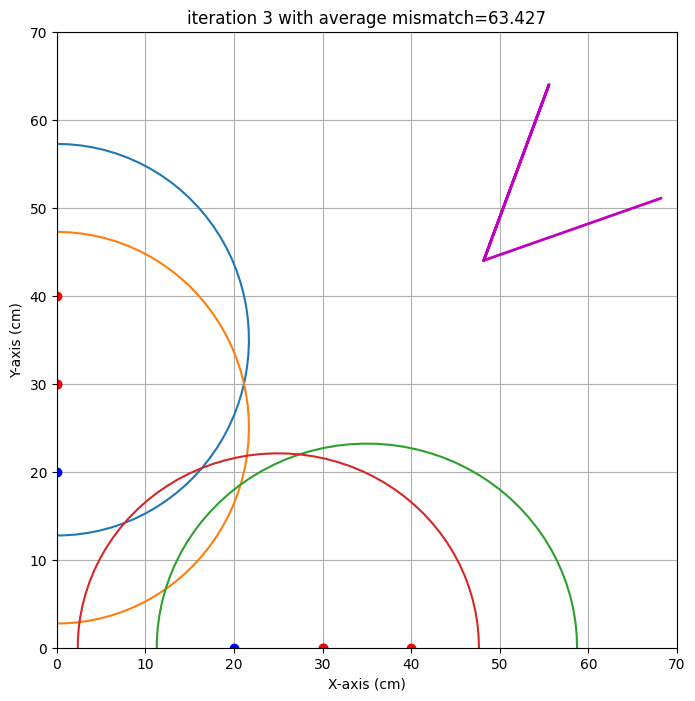

end iteration 3 with average mismatch=63.427


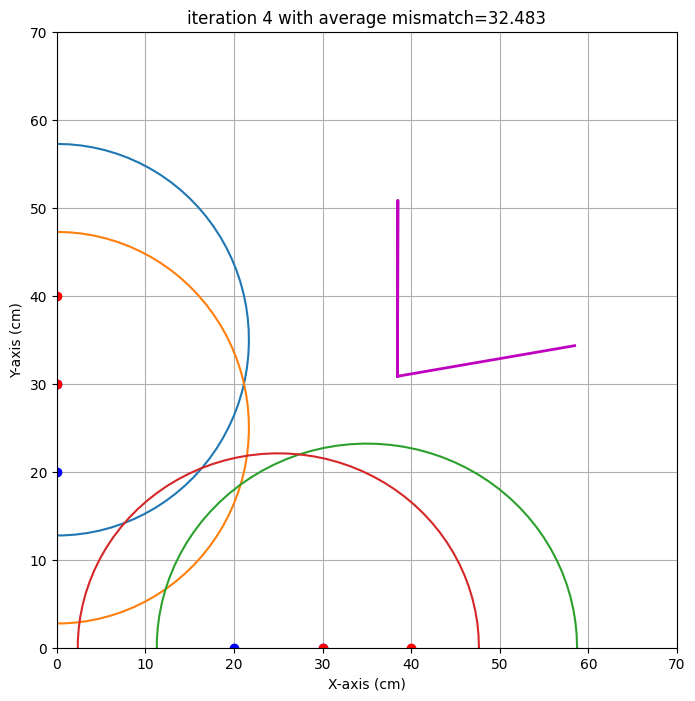

end iteration 4 with average mismatch=32.483


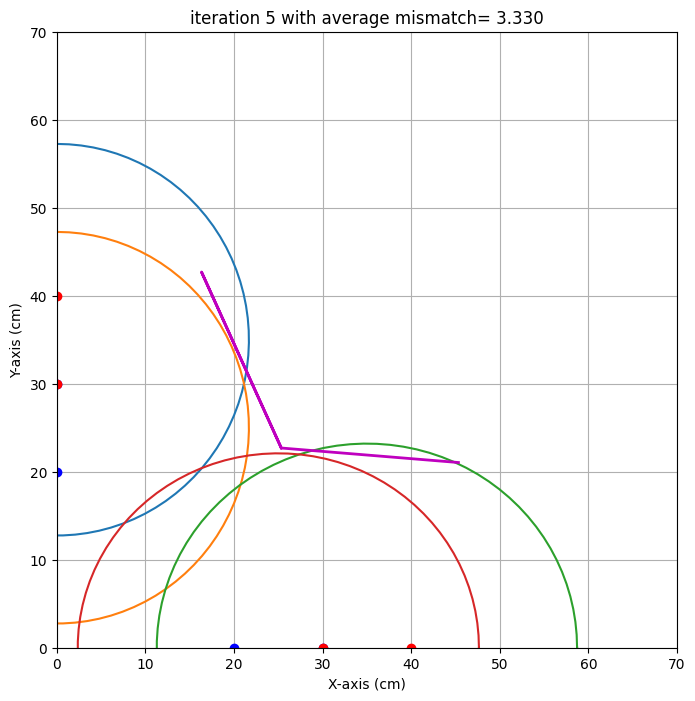

end iteration 5 with average mismatch= 3.330


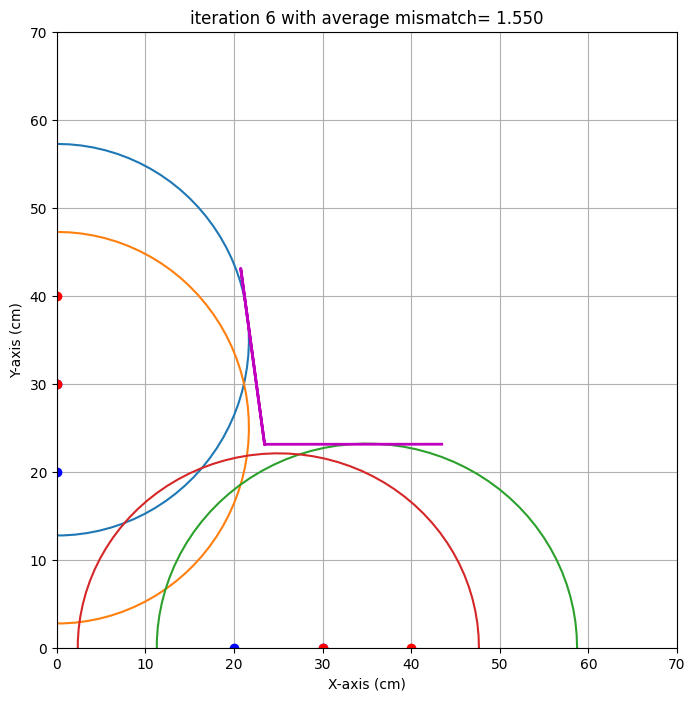

end iteration 6 with average mismatch= 1.550


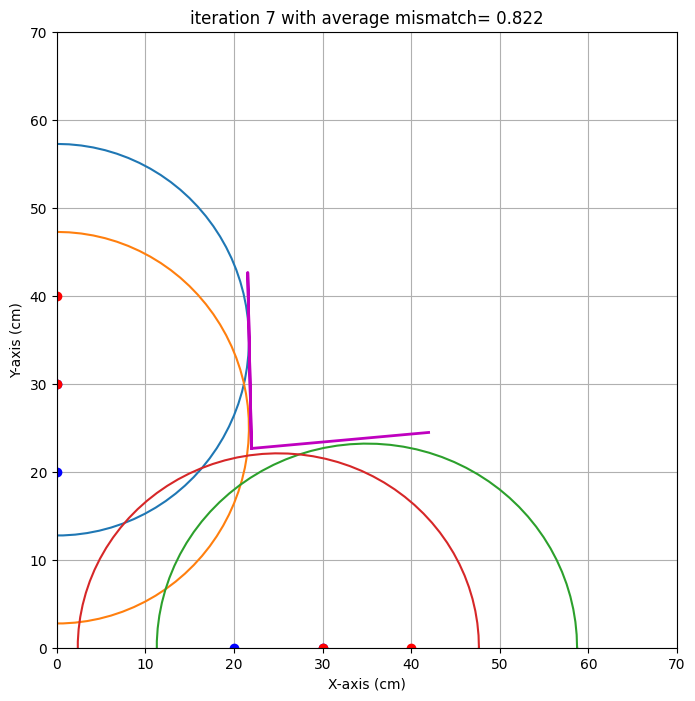

end iteration 7 with average mismatch= 0.822


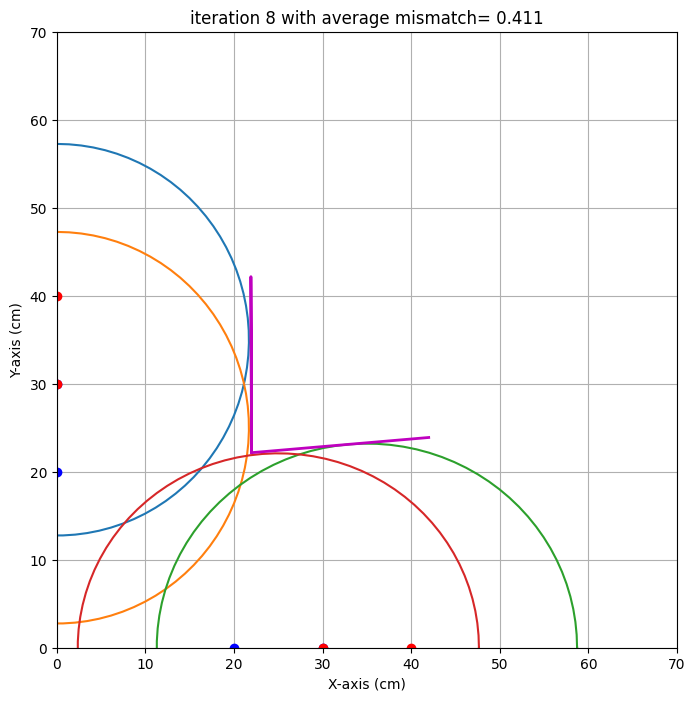

end iteration 8 with average mismatch= 0.411
end iteration 9 with average mismatch= 0.398


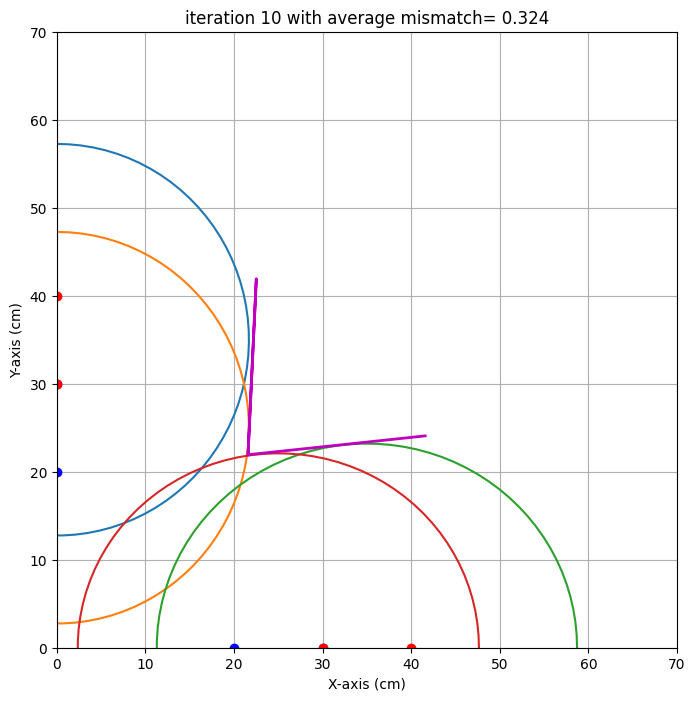

end iteration 10 with average mismatch= 0.324


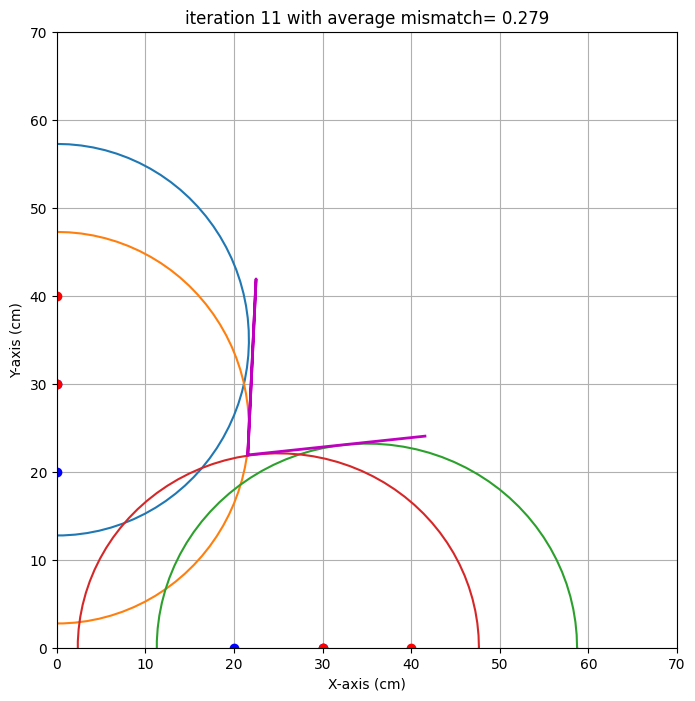

end iteration 11 with average mismatch= 0.279
end iteration 12 with average mismatch= 0.279
end iteration 13 with average mismatch= 0.279
end iteration 14 with average mismatch= 0.279
end iteration 15 with average mismatch= 0.279
end iteration 16 with average mismatch= 0.279
end iteration 17 with average mismatch= 0.279
end iteration 18 with average mismatch= 0.279
end iteration 19 with average mismatch= 0.279
end iteration 20 with average mismatch= 0.279
end iteration 21 with average mismatch= 0.279
end iteration 22 with average mismatch= 0.279
end iteration 23 with average mismatch= 0.279
end iteration 24 with average mismatch= 0.279
end iteration 25 with average mismatch= 0.279
end iteration 26 with average mismatch= 0.279
end iteration 27 with average mismatch= 0.279
end iteration 28 with average mismatch= 0.279
end iteration 29 with average mismatch= 0.279
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

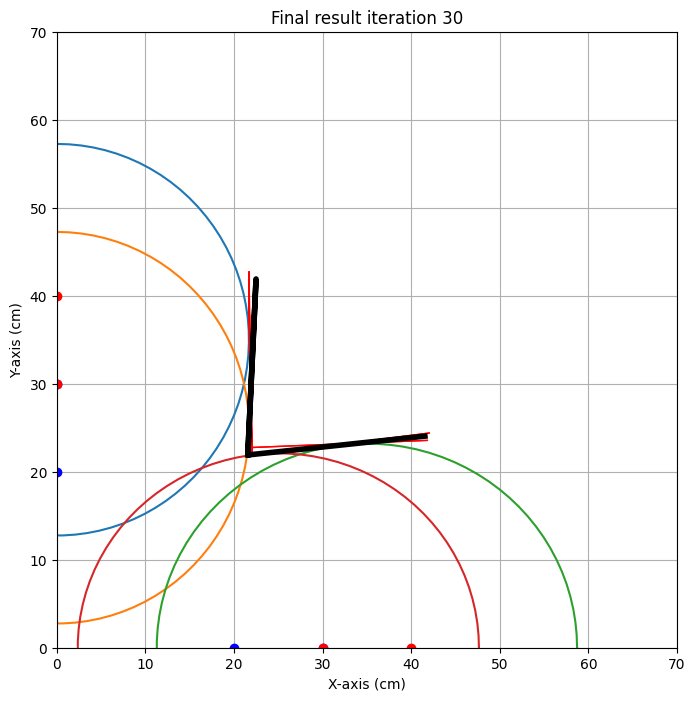

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

# Zeven metingen gedaan, maar 3 waren ongeldig ((0,10),(0,20)) en ((10,0),(20,0)) en ((10,0),(0,10))
Test_meting = np.array([44.50,44.50,47.46,45.30])

dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,Test_meting[0]],
    [0,30,0,20,Test_meting[1]],
    #[0,10,0,20,Test_meting[2]],
    [40,0,30,0,Test_meting[2]],
    [30,0,20,0,Test_meting[3]]
    #[10,0,20,0,Test_meting[4]],
    #[10,0,0,10,Test_meting[5]]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.6 cm met een standaardafwijking van 0.5 cm 
y0: 21.9 cm met een standaardafwijking van 0.8 cm 
alpha: 6.1 graden met een standaardafwijking van 3.8 graad 
beta: 2.7 graden met een standaardafwijking van 3.8 graad 



## Opdracht 5: Iteratie 0

#### algoritme Sybren
<img src="Algoritme_Sybren.jpeg" width="400">

#### algoritme Alesja
<img src="Algoritme_Alesja.jpeg" width="400">

#### algoritme Daan
<img src="Algoritme_Daan.jpeg" width="400">

Tijdens het testen van de algoritmes is gebruik gemaakt van een object met x0 = 29, y0 = 36, alpha = 0 en  beta = 0

## Opdracht 6: Test iteratie 0.

In [6]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':29,  #zelf aanvullen,
           'y0':36, #zelf aanvullen,
           'alpha' :1, #zelf aanvullen,
           'beta' :1 #zelf aanvullen},
          }
           
Algoritme_Alesja = np.array([80.16,80.12,63.59,61.80])
Algoritme_Daan = np.array([84.29,78.30,79.64,56.72,56.93,56.36])
# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Alesja' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
         [40,0,55,0,Algoritme_Alesja[0]],
         [30,0,45,0,Algoritme_Alesja[1]],
         [0,30,0,45,Algoritme_Alesja[2]],
         [0,40,0,55,Algoritme_Alesja[3]]
         ]),
      'Daan' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [30,0,20,0,Algoritme_Daan[0]],
        [40,0,30,0,Algoritme_Daan[1]],
        #[25,0,15,0,Algoritme_Daan[2]], #fout
        [45,0,35,0,Algoritme_Daan[2]],
        #[0,30,0,20,Algoritme_Daan[3]], #fout
        [0,50,0,40,Algoritme_Daan[3]],
        [0,60,0,50,Algoritme_Daan[4]],
        [0,65,0,55,Algoritme_Daan[5]]
         ])
      }

## Opdracht 7: Evaluatie.

Alesja
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  55   0  80.16
1  30   0  45   0  80.12
2   0  30   0  45  63.59
3   0  40   0  55  61.80


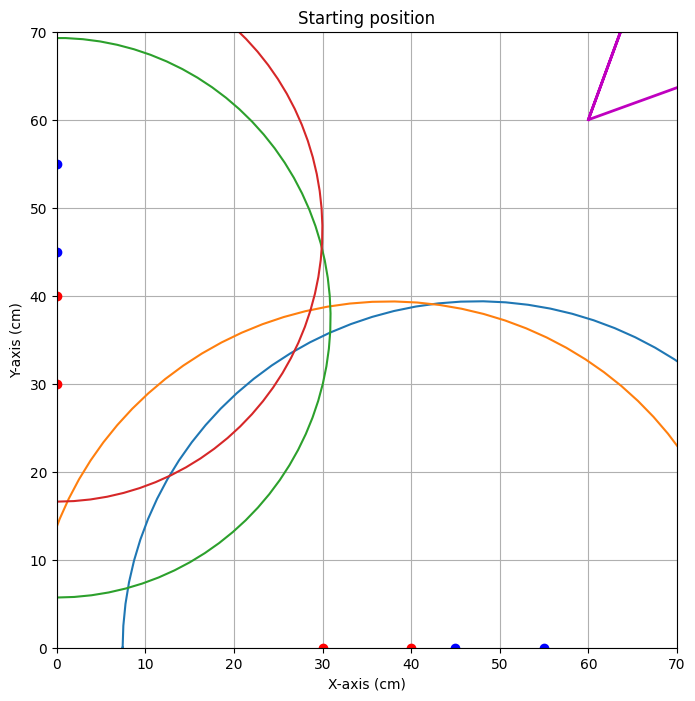


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.359


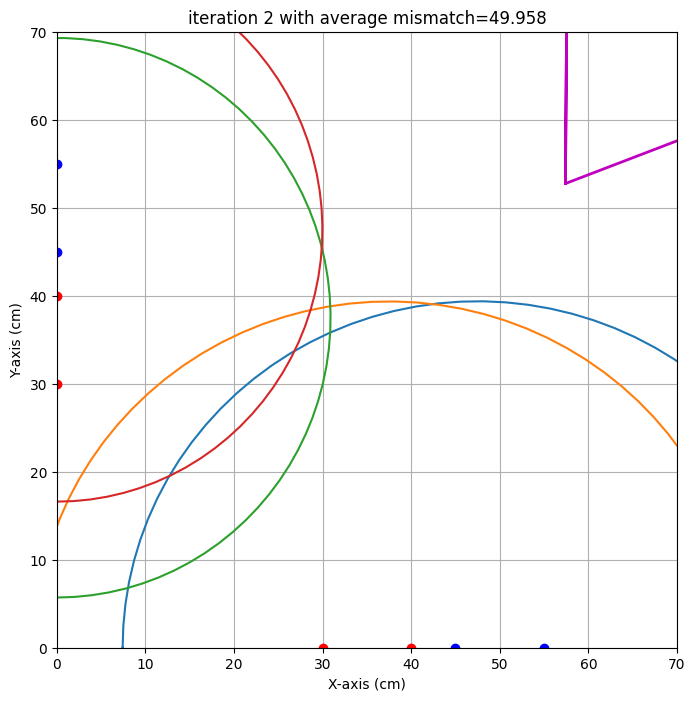

end iteration 2 with average mismatch=49.958


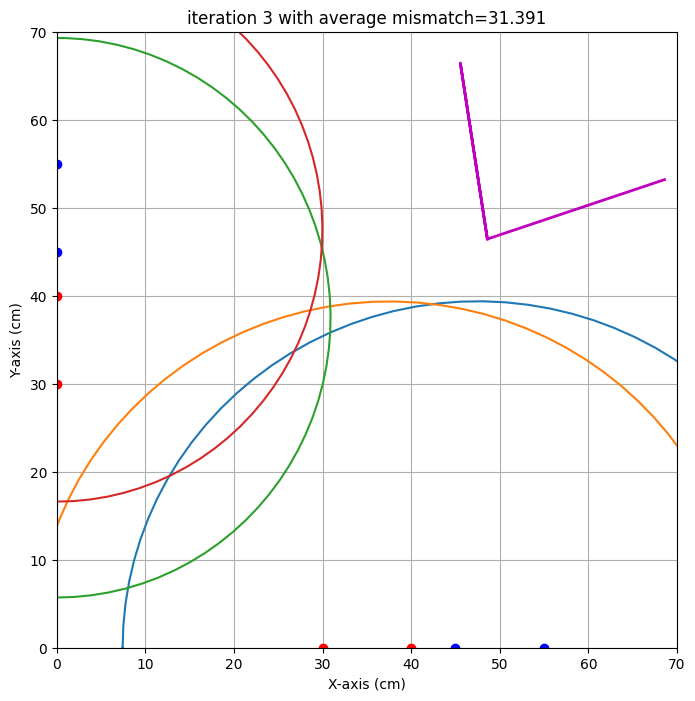

end iteration 3 with average mismatch=31.391


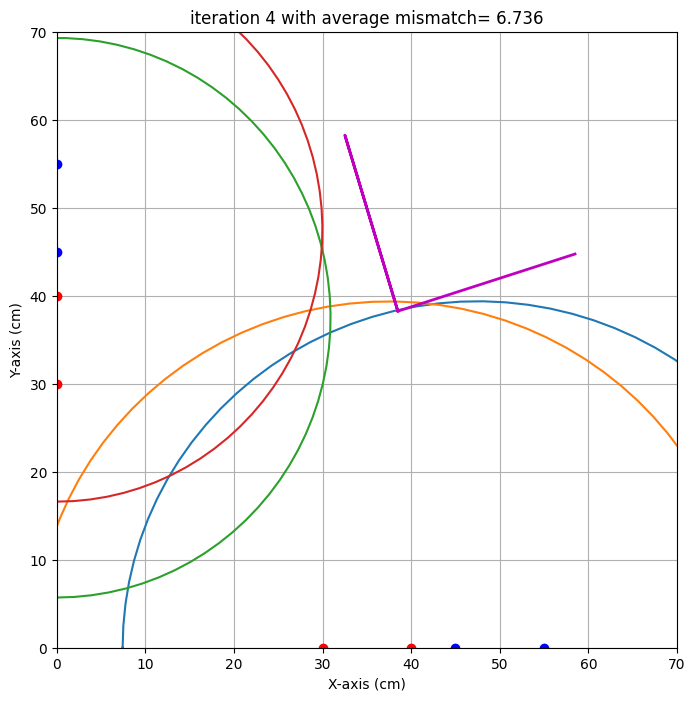

end iteration 4 with average mismatch= 6.736


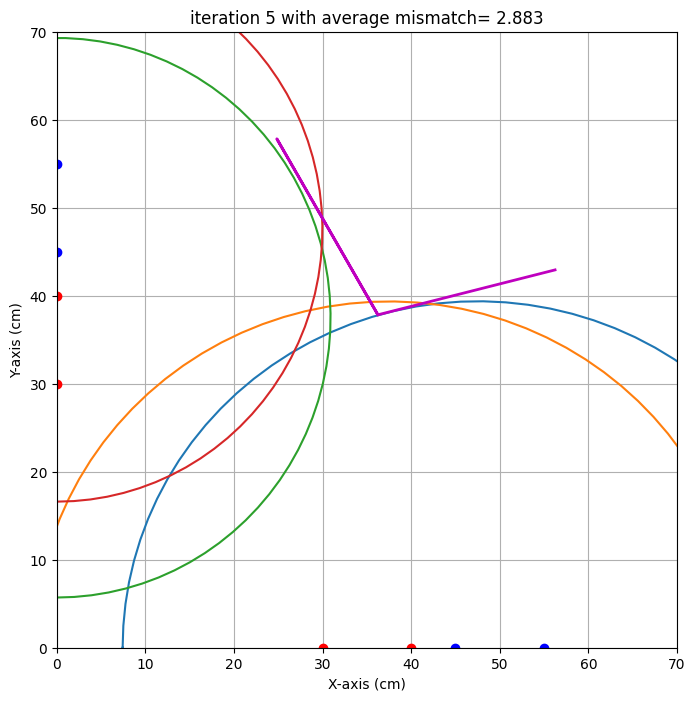

end iteration 5 with average mismatch= 2.883


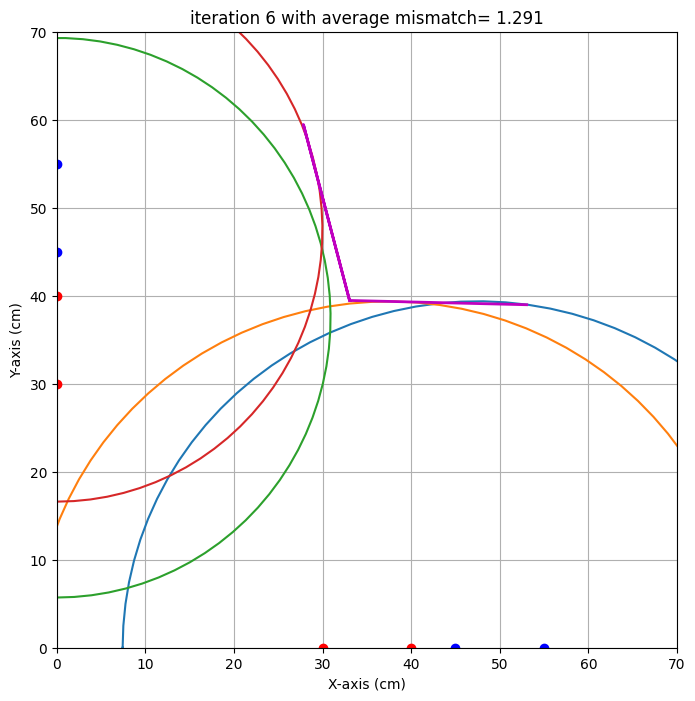

end iteration 6 with average mismatch= 1.291


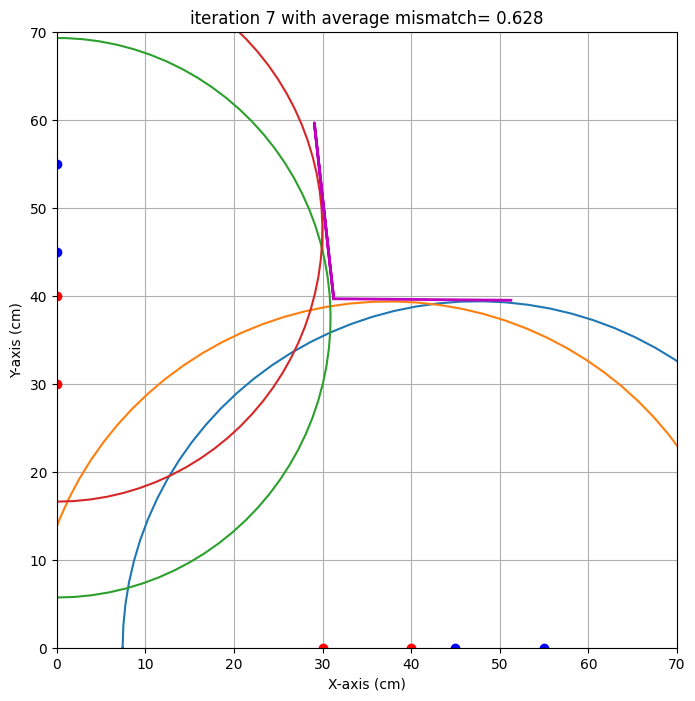

end iteration 7 with average mismatch= 0.628


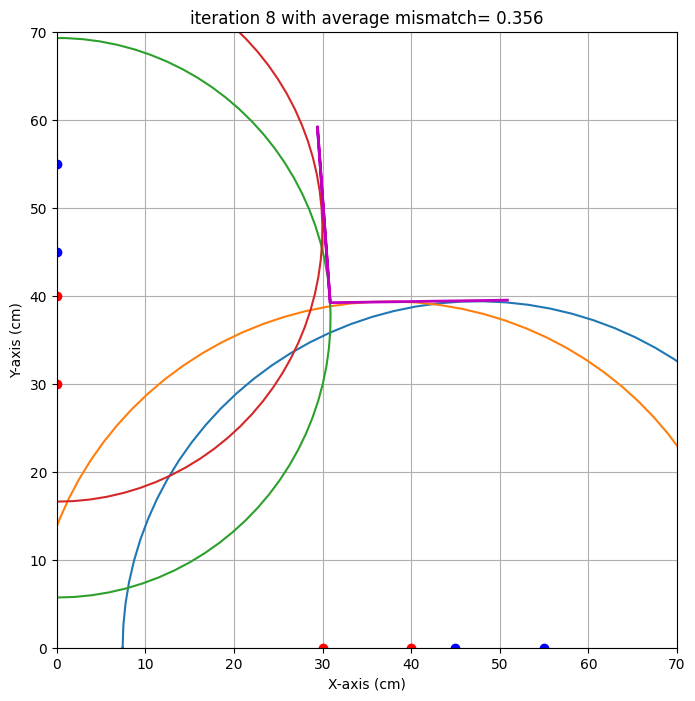

end iteration 8 with average mismatch= 0.356


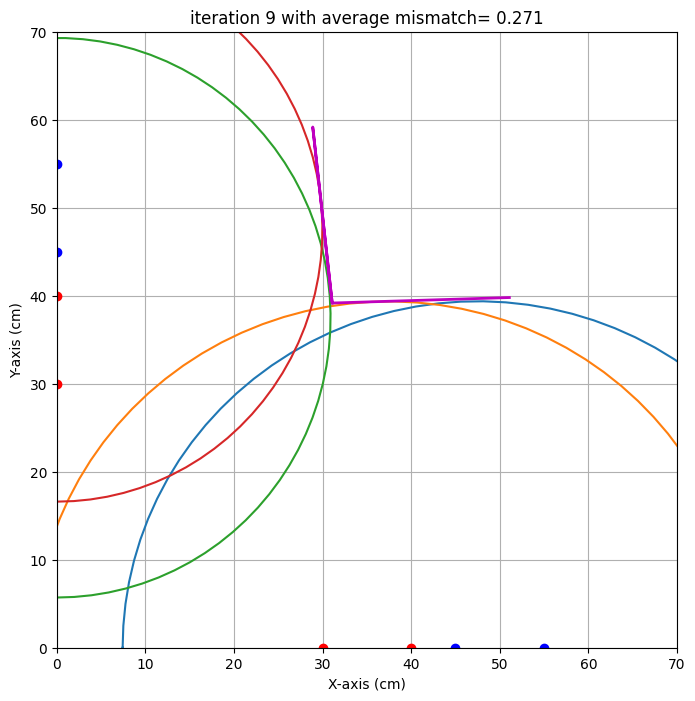

end iteration 9 with average mismatch= 0.271
end iteration 10 with average mismatch= 0.271


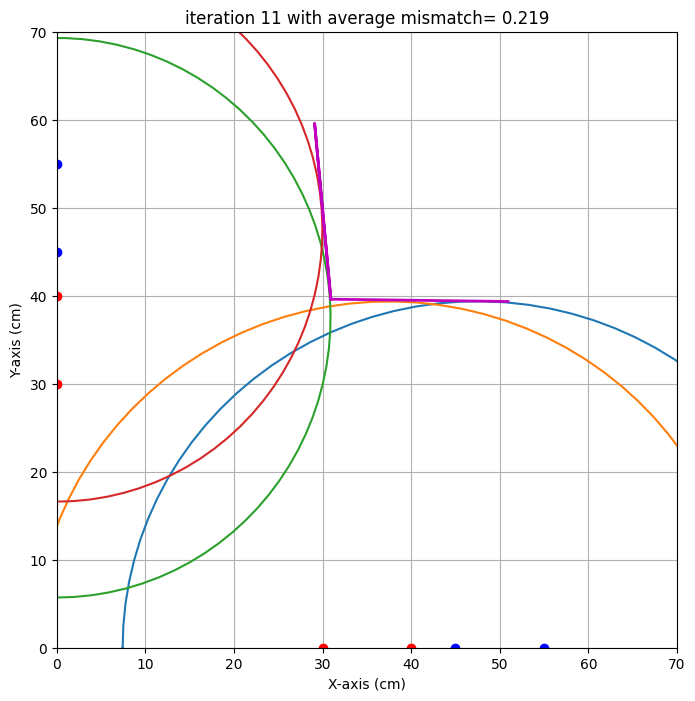

end iteration 11 with average mismatch= 0.219
end iteration 12 with average mismatch= 0.200
end iteration 13 with average mismatch= 0.192
end iteration 14 with average mismatch= 0.191
end iteration 15 with average mismatch= 0.191
end iteration 16 with average mismatch= 0.191


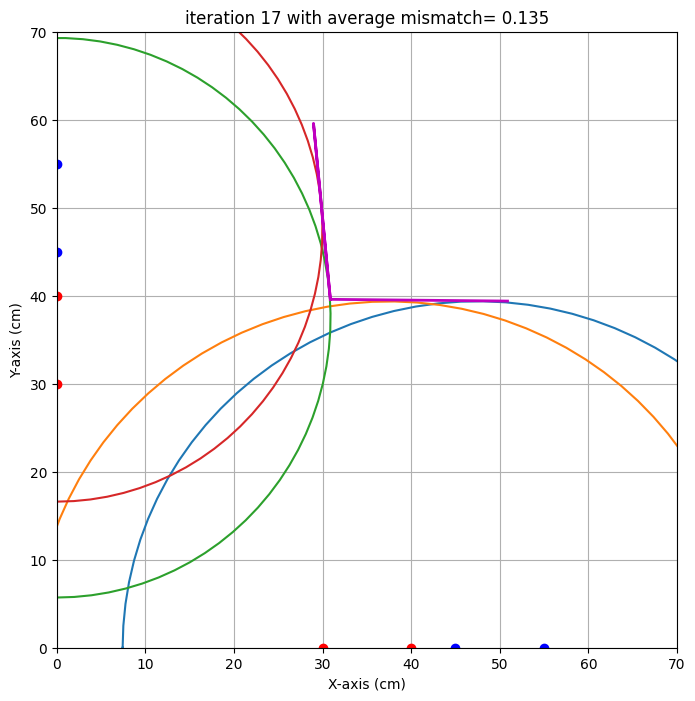

end iteration 17 with average mismatch= 0.135
end iteration 18 with average mismatch= 0.129
end iteration 19 with average mismatch= 0.128
end iteration 20 with average mismatch= 0.127
end iteration 21 with average mismatch= 0.127
end iteration 22 with average mismatch= 0.127
end iteration 23 with average mismatch= 0.127
end iteration 24 with average mismatch= 0.127
end iteration 25 with average mismatch= 0.127
end iteration 26 with average mismatch= 0.127
end iteration 27 with average mismatch= 0.127
end iteration 28 with average mismatch= 0.127
end iteration 29 with average mismatch= 0.127
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.127
###############################################################################
end of iteration  30
Best alpha=  -0.57 with uncertainty=   0.96
Best beta =  -5.45 with uncertainty=   0.65
Best x0   =  30.87 with uncertain

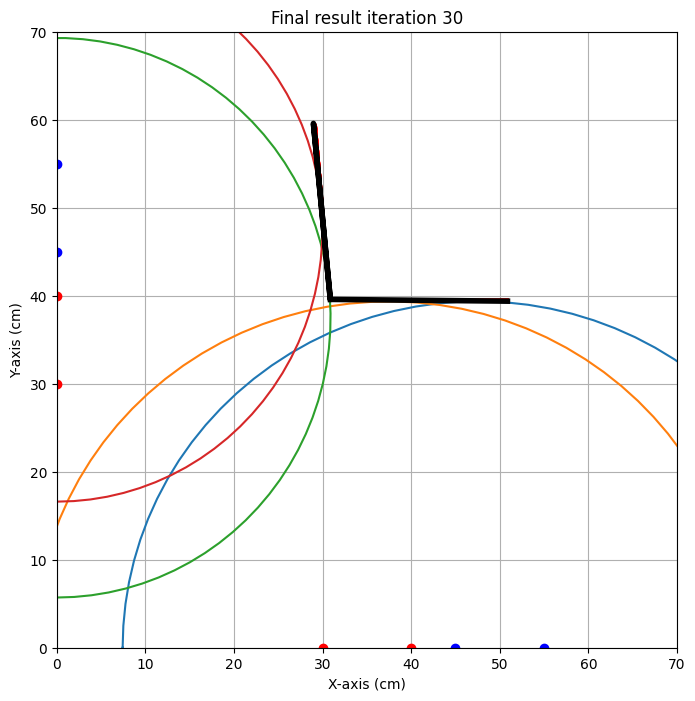

{'alpha': np.float64(-0.5679507763243612), 'alpha_eps': np.float64(0.9645349613396333), 'beta': np.float64(-5.45128478336701), 'beta_eps': np.float64(0.6470853990553618), 'x0': np.float64(30.86929048713092), 'x0_eps': np.float64(0.08600777792129577), 'y0': np.float64(39.58098564357912), 'y0_eps': np.float64(0.11681961906567295)}
Daan
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  20   0  84.29
1  40   0  30   0  78.30
2  45   0  35   0  79.64
3   0  50   0  40  56.72
4   0  60   0  50  56.93
5   0  65   0  55  56.36


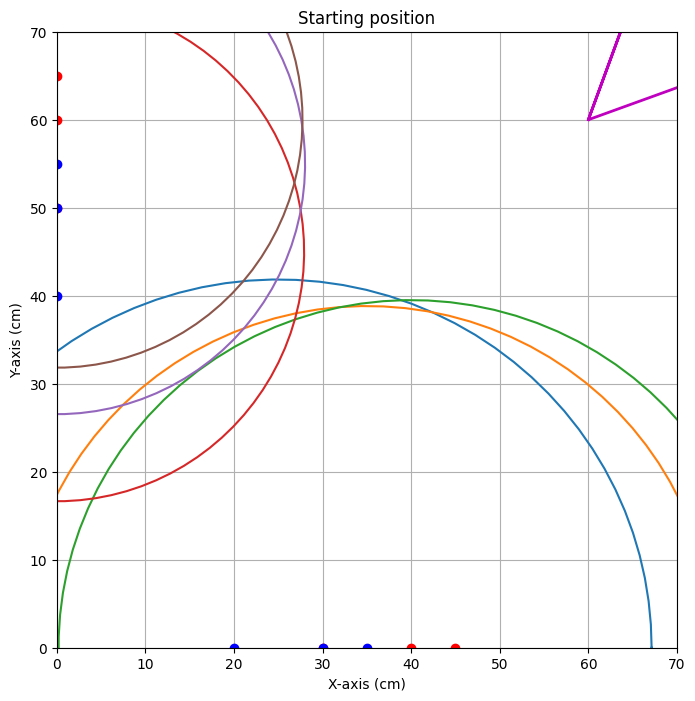


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.988


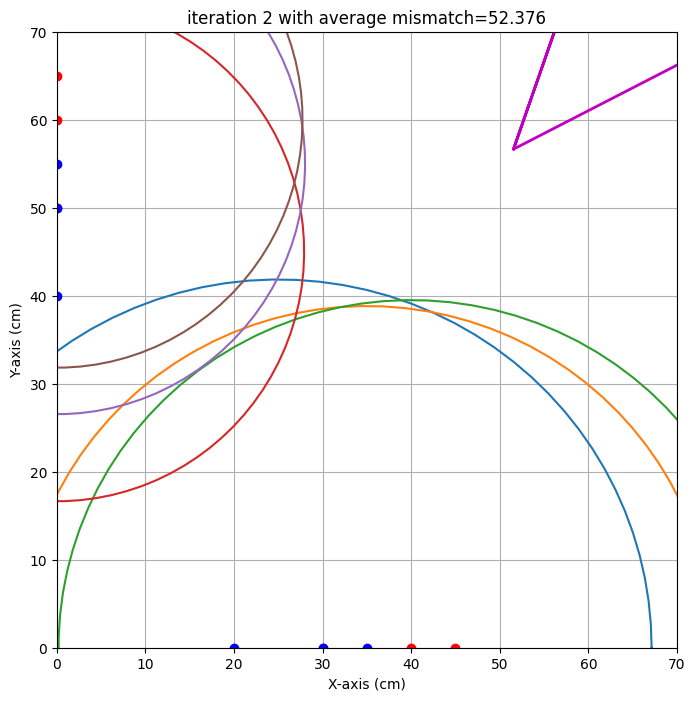

end iteration 2 with average mismatch=52.376


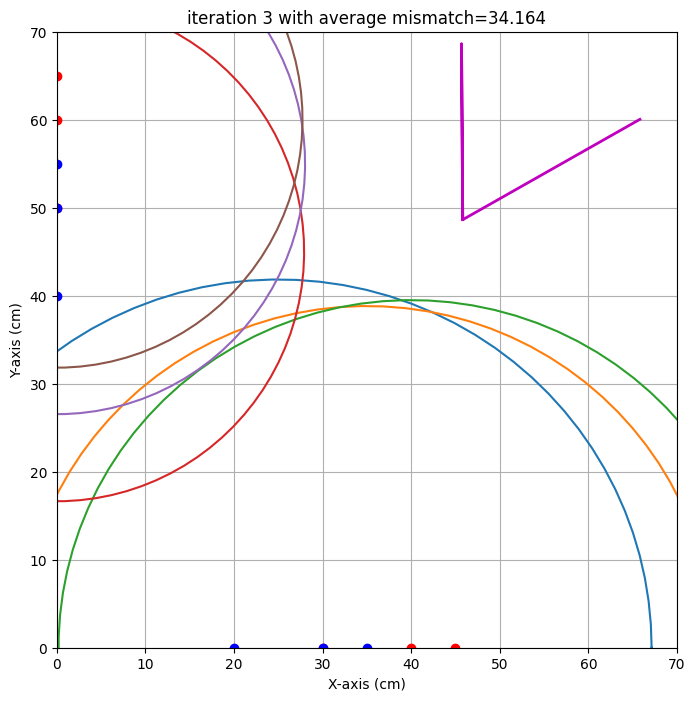

end iteration 3 with average mismatch=34.164


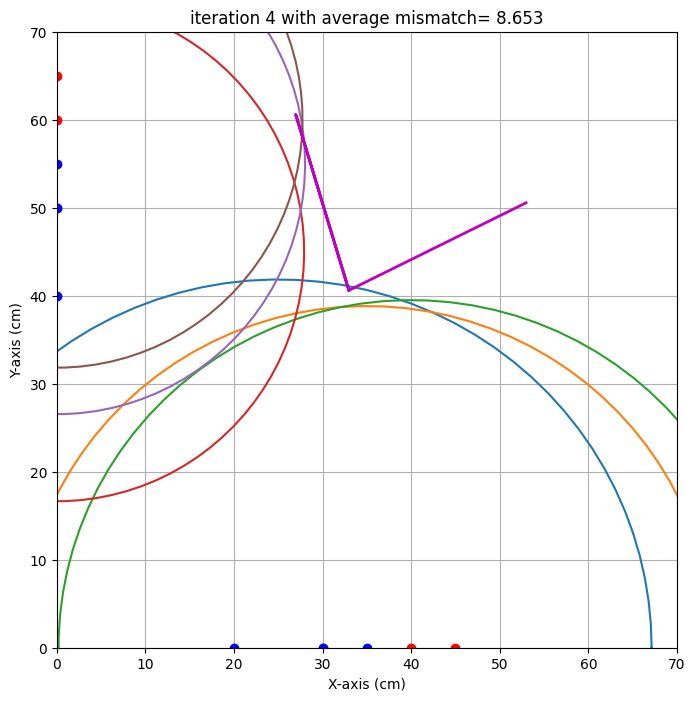

end iteration 4 with average mismatch= 8.653


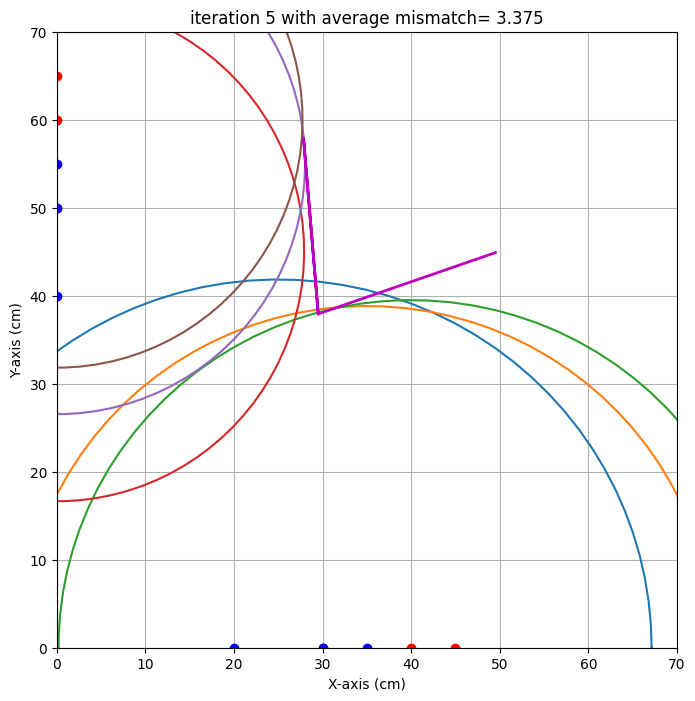

end iteration 5 with average mismatch= 3.375


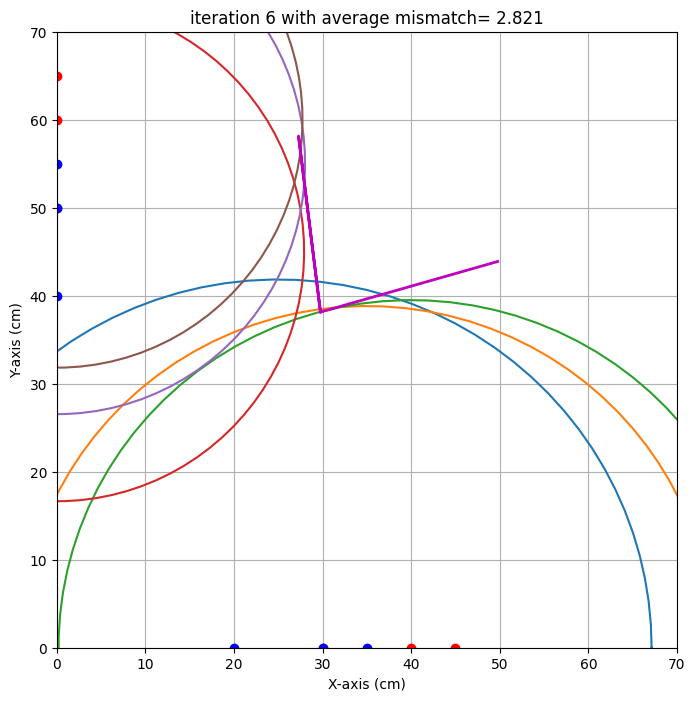

end iteration 6 with average mismatch= 2.821


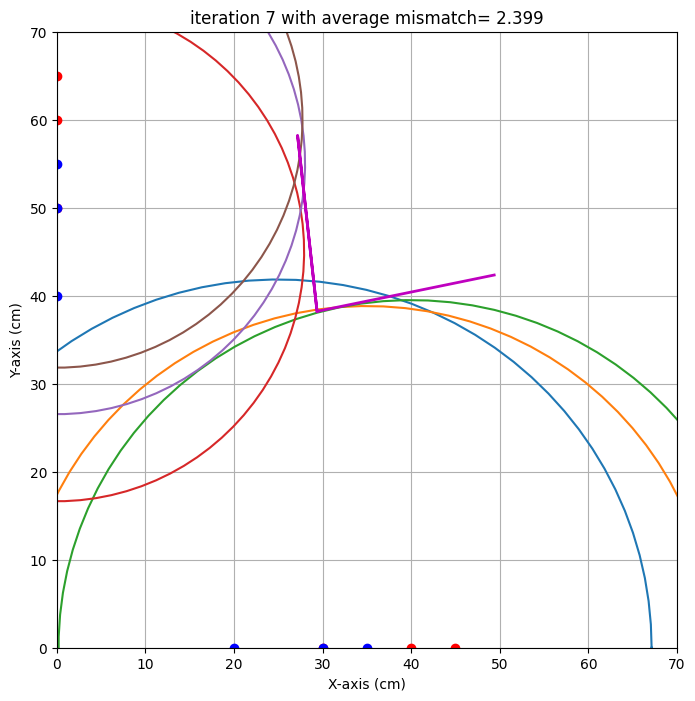

end iteration 7 with average mismatch= 2.399


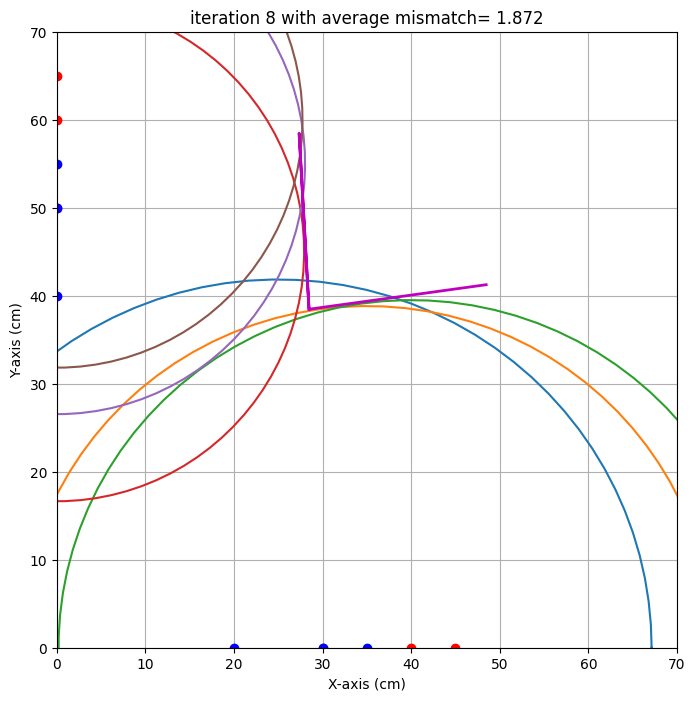

end iteration 8 with average mismatch= 1.872
end iteration 9 with average mismatch= 1.785
end iteration 10 with average mismatch= 1.731
end iteration 11 with average mismatch= 1.620
end iteration 12 with average mismatch= 1.594
end iteration 13 with average mismatch= 1.594
end iteration 14 with average mismatch= 1.594
end iteration 15 with average mismatch= 1.594
end iteration 16 with average mismatch= 1.594
end iteration 17 with average mismatch= 1.594
end iteration 18 with average mismatch= 1.557
end iteration 19 with average mismatch= 1.552
end iteration 20 with average mismatch= 1.551
end iteration 21 with average mismatch= 1.479
end iteration 22 with average mismatch= 1.479
end iteration 23 with average mismatch= 1.479
end iteration 24 with average mismatch= 1.413


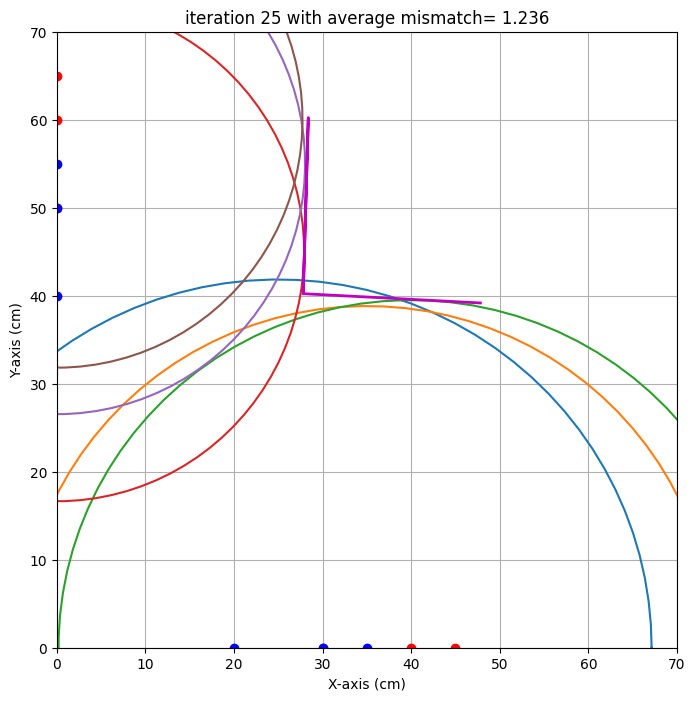

end iteration 25 with average mismatch= 1.236
end iteration 26 with average mismatch= 1.198


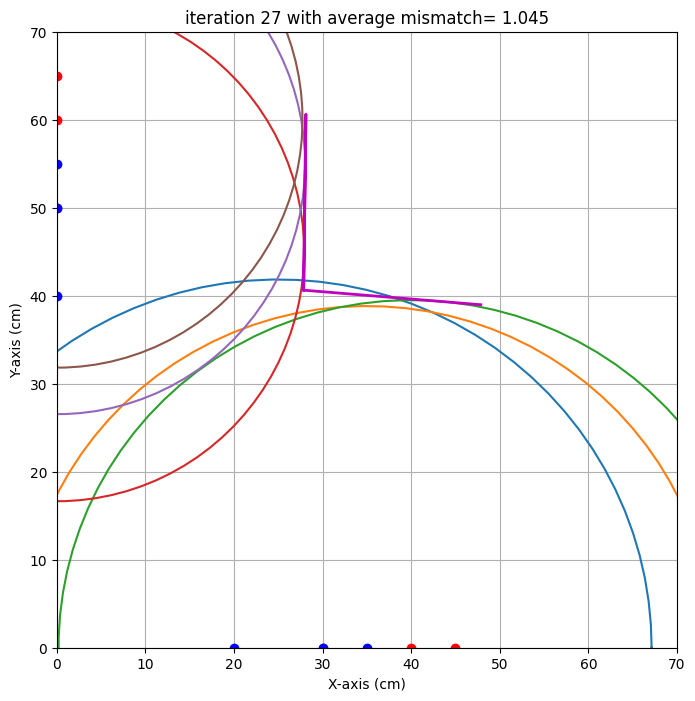

end iteration 27 with average mismatch= 1.045


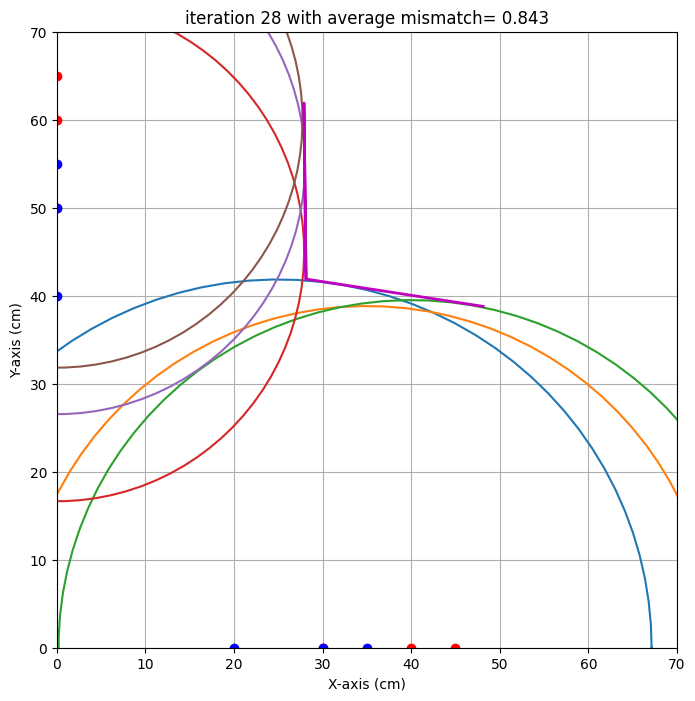

end iteration 28 with average mismatch= 0.843
end iteration 29 with average mismatch= 0.824
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.819
###############################################################################
end of iteration  30
Best alpha=  -8.84 with uncertainty=   3.25
Best beta =  -0.65 with uncertainty=   1.78
Best x0   =  28.12 with uncertainty=   0.20
Best y0   =  41.87 with uncertainty=   0.77
###############################################################################


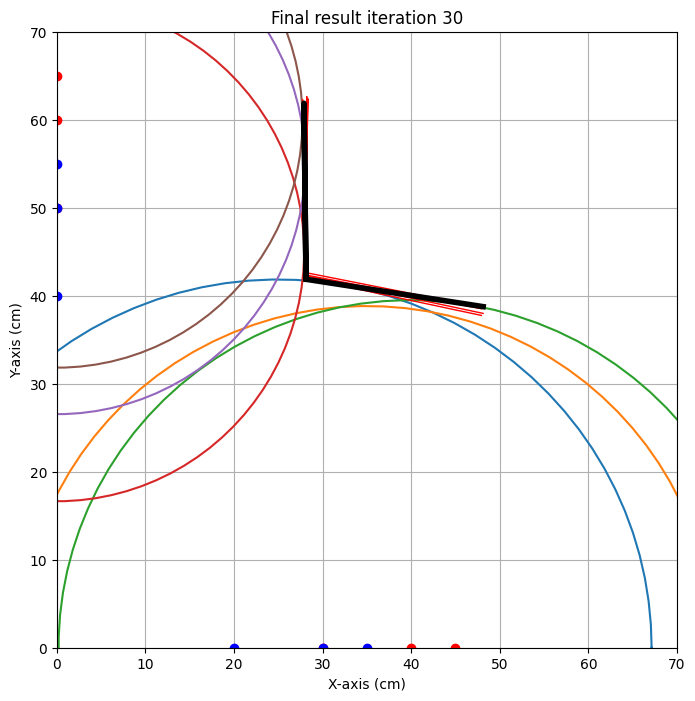

{'alpha': np.float64(-8.840411052725507), 'alpha_eps': np.float64(3.248828016590952), 'beta': np.float64(-0.6533728958837183), 'beta_eps': np.float64(1.777153369598493), 'x0': np.float64(28.1239366974761), 'x0_eps': np.float64(0.20477853342882213), 'y0': np.float64(41.869430698958965), 'y0_eps': np.float64(0.7691480408912739)}


In [7]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

studentNames = ['Alesja','Daan'] # Sybren is hier weggehaald gezien die Algoritme niet is getest. Anders kwam er een error

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [8]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Alesja 
x0 target is : 29.0. Gevonden waarde: 30.9 cm met een standaardafwijking van 0.1 cm 
y0 target is : 36.0. Gevonden waarde: 39.6 cm met een standaardafwijking van 0.1 cm 
alpha target is : 1.0. Gevonden waarde: -0.6 graden met een standaardafwijking van 1.0 graad 
beta target is : 1.0. Gevonden waarde: -5.5 graden met een standaardafwijking van 0.6 graad 

Daan 
x0 target is : 29.0. Gevonden waarde: 28.1 cm met een standaardafwijking van 0.2 cm 
y0 target is : 36.0. Gevonden waarde: 41.9 cm met een standaardafwijking van 0.8 cm 
alpha target is : 1.0. Gevonden waarde: -8.8 graden met een standaardafwijking van 3.2 graad 
beta target is : 1.0. Gevonden waarde: -0.7 graden met een standaardafwijking van 1.8 graad 



## Opdracht 8: Iteratie1+. 14:50
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

![Alt](Verbeterd_algoritme.jpeg)


In [9]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0  50   0  30   0   98.10
1  60   0  40   0   98.62
2  65   0  45   0  101.27
3   0  50   0  30   74.68
4   0  60   0  40   68.28
5   0  65   0  45   67.41


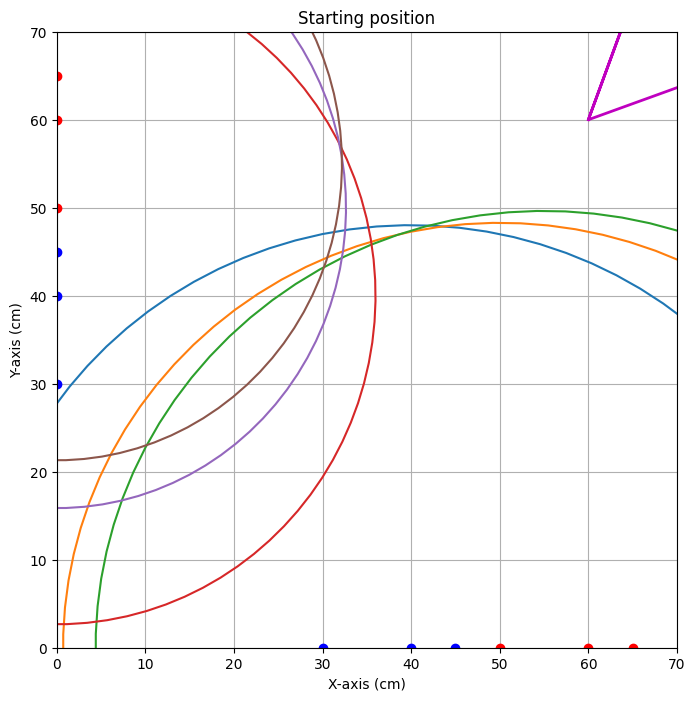


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.831


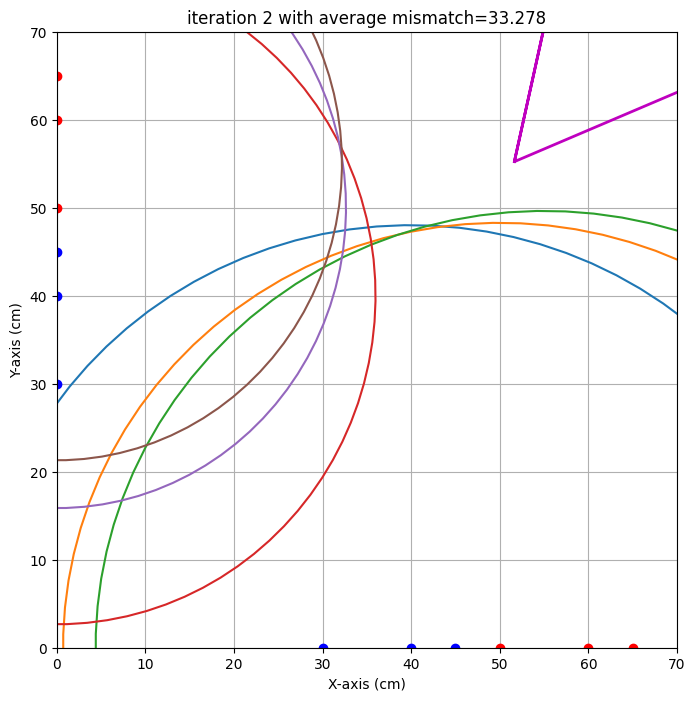

end iteration 2 with average mismatch=33.278


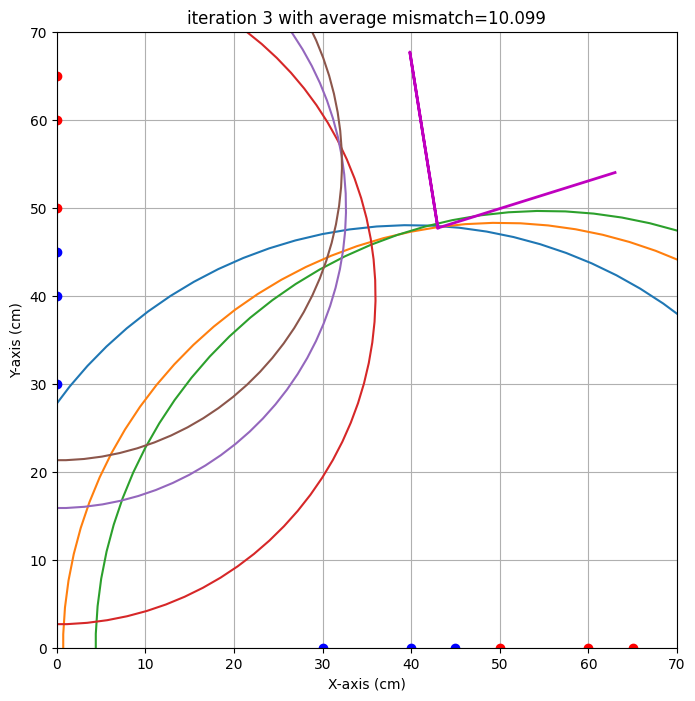

end iteration 3 with average mismatch=10.099


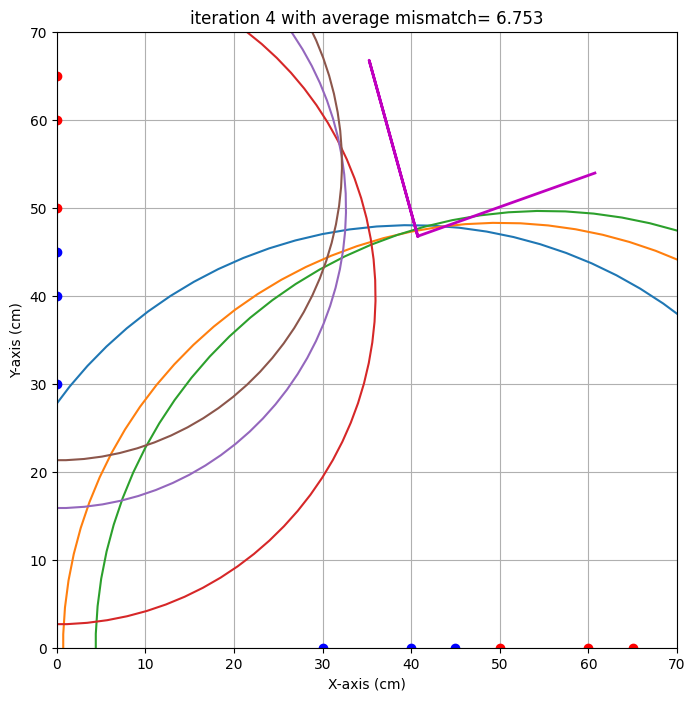

end iteration 4 with average mismatch= 6.753


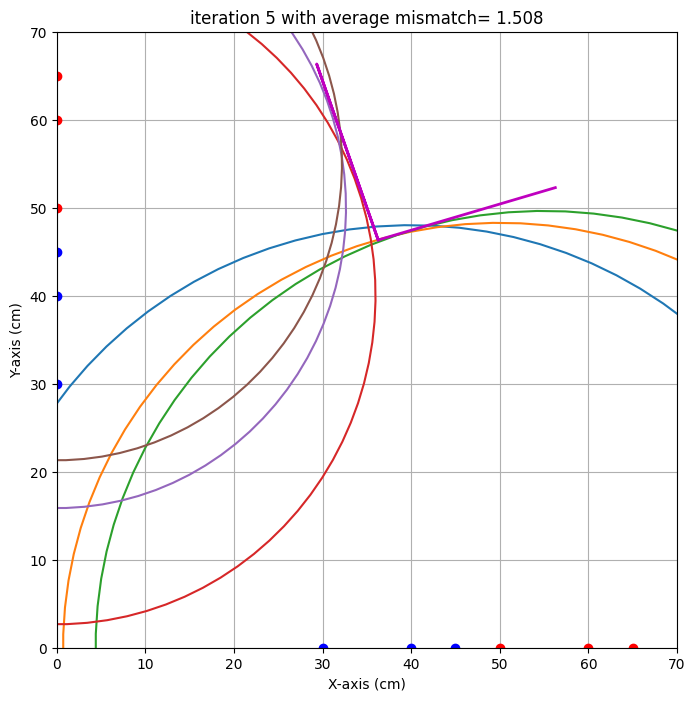

end iteration 5 with average mismatch= 1.508
end iteration 6 with average mismatch= 1.378
end iteration 7 with average mismatch= 1.360
end iteration 8 with average mismatch= 1.326


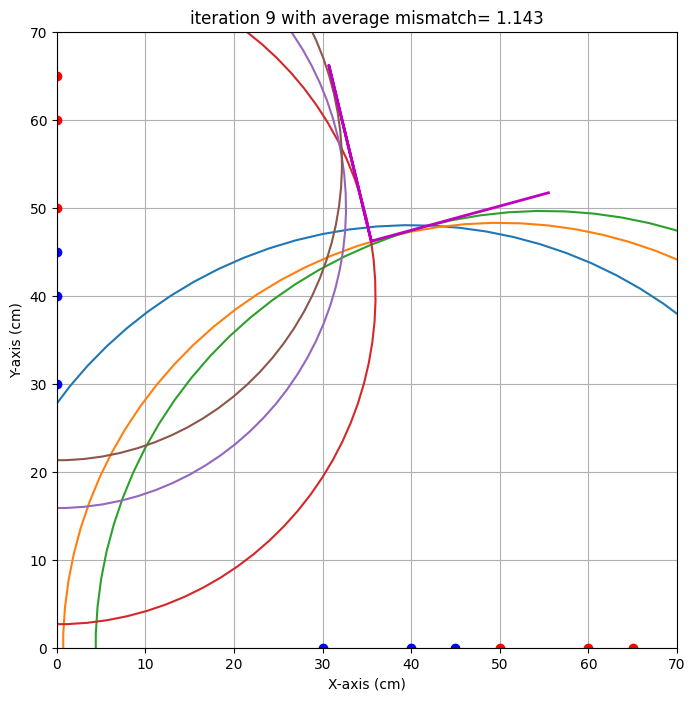

end iteration 9 with average mismatch= 1.143
end iteration 10 with average mismatch= 1.140
end iteration 11 with average mismatch= 1.090
end iteration 12 with average mismatch= 1.032
end iteration 13 with average mismatch= 1.032
end iteration 14 with average mismatch= 1.032
end iteration 15 with average mismatch= 1.032
end iteration 16 with average mismatch= 1.032
end iteration 17 with average mismatch= 1.032
end iteration 18 with average mismatch= 1.032
end iteration 19 with average mismatch= 1.032
end iteration 20 with average mismatch= 1.032
end iteration 21 with average mismatch= 1.032
end iteration 22 with average mismatch= 1.032
end iteration 23 with average mismatch= 0.988
end iteration 24 with average mismatch= 0.974
end iteration 25 with average mismatch= 0.961
end iteration 26 with average mismatch= 0.957
end iteration 27 with average mismatch= 0.956
end iteration 28 with average mismatch= 0.956
end iteration 29 with average mismatch= 0.956
Last iteration, also determine unce

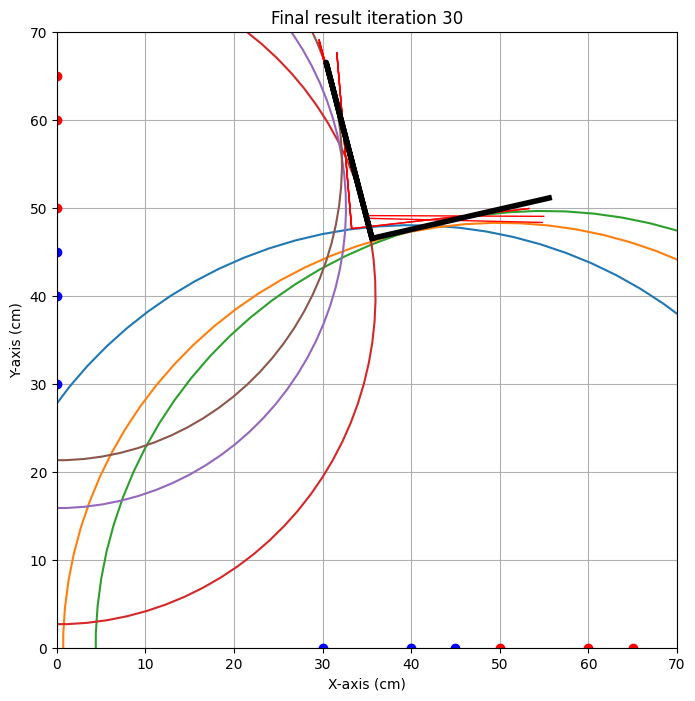

{'alpha': np.float64(12.926363297488331), 'alpha_eps': np.float64(14.292016231305581), 'beta': np.float64(-14.520479954515716), 'beta_eps': np.float64(9.722243886816372), 'x0': np.float64(35.573767095957955), 'x0_eps': np.float64(2.293270346139039), 'y0': np.float64(46.51723681355948), 'y0_eps': np.float64(2.58795621473368)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  10   0  62.09
1  40   0  20   0  61.15
2  45   0  25   0  62.60
3   0  50   0  30  54.61
4   0  60   0  40  58.45
5   0  65   0  45  60.70


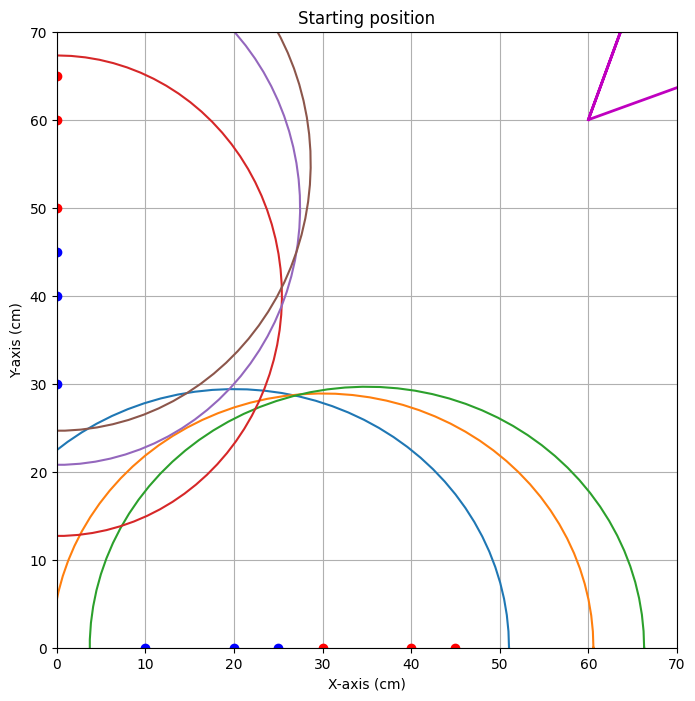


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=76.889


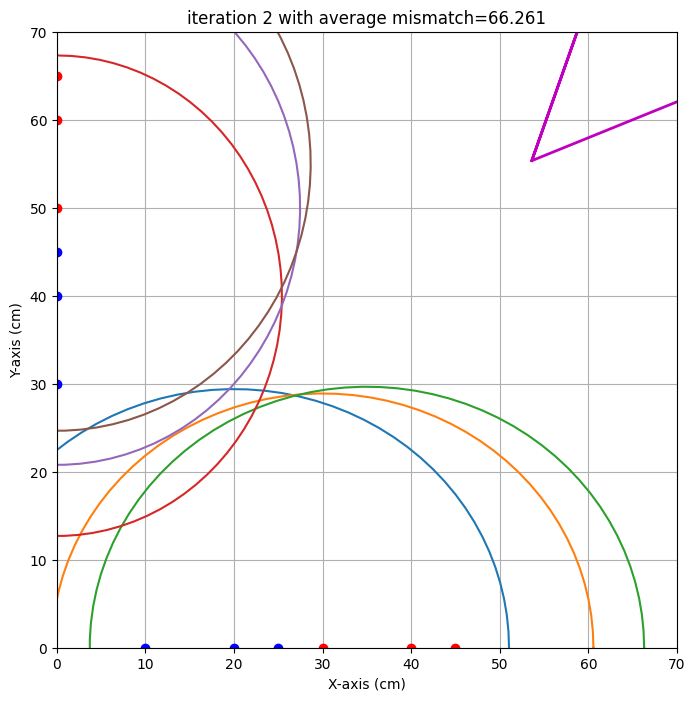

end iteration 2 with average mismatch=66.261


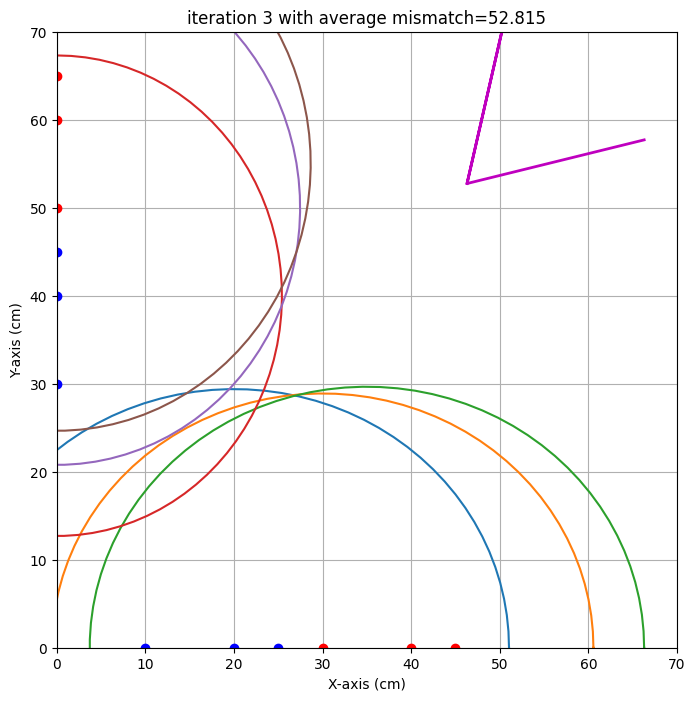

end iteration 3 with average mismatch=52.815


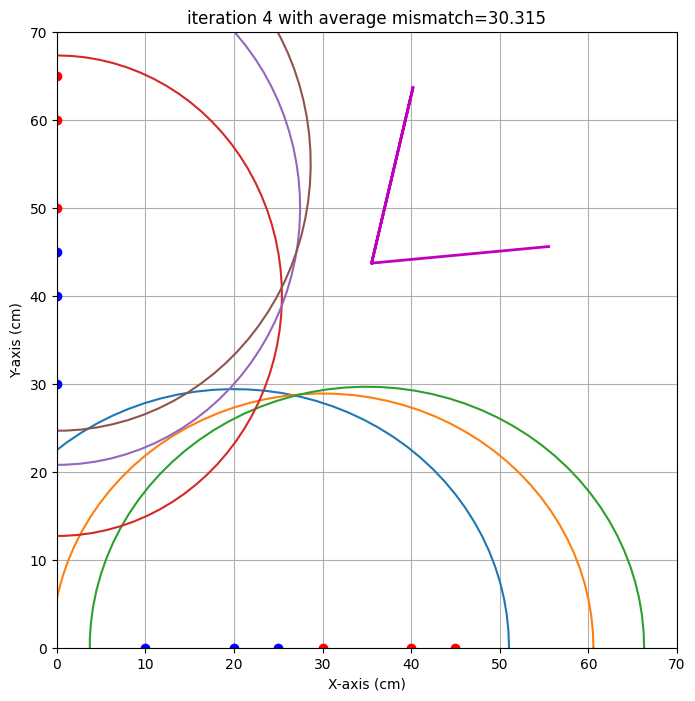

end iteration 4 with average mismatch=30.315


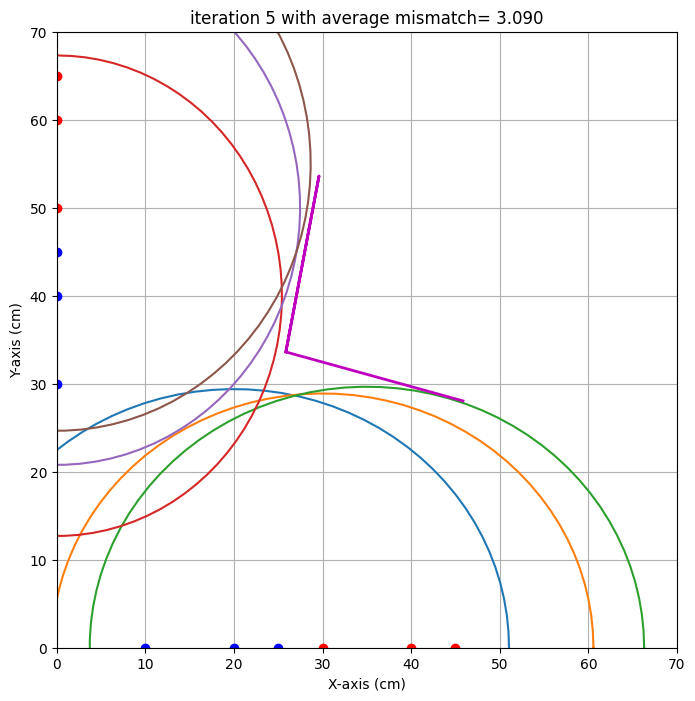

end iteration 5 with average mismatch= 3.090


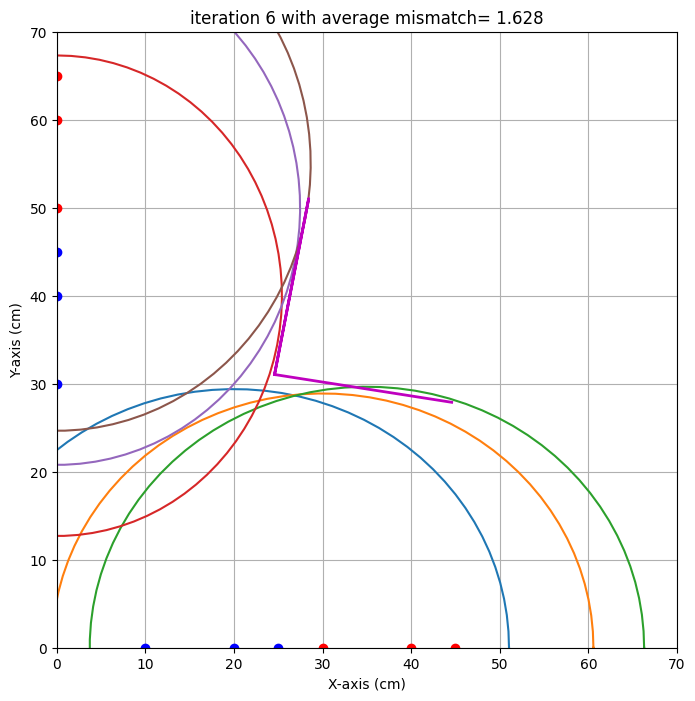

end iteration 6 with average mismatch= 1.628


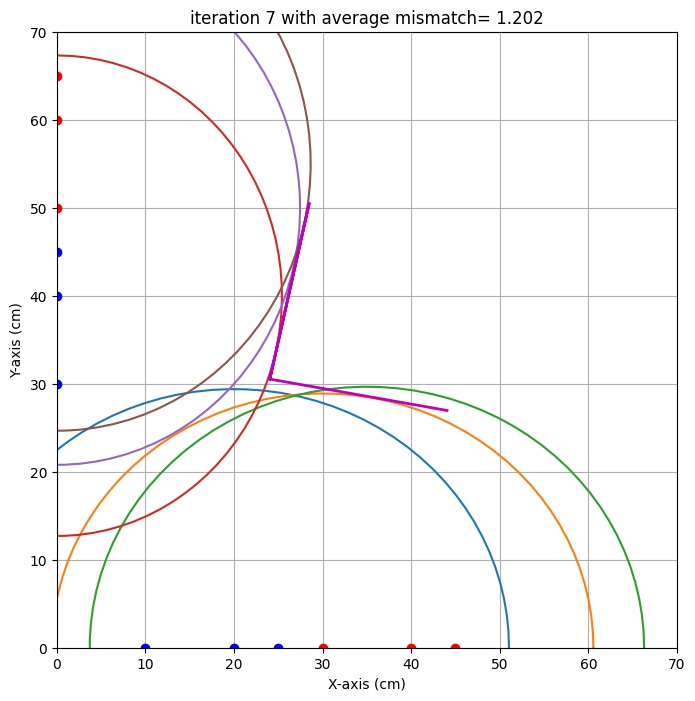

end iteration 7 with average mismatch= 1.202
end iteration 8 with average mismatch= 1.181
end iteration 9 with average mismatch= 1.098
end iteration 10 with average mismatch= 1.097
end iteration 11 with average mismatch= 1.097
end iteration 12 with average mismatch= 1.097
end iteration 13 with average mismatch= 1.097
end iteration 14 with average mismatch= 1.097
end iteration 15 with average mismatch= 1.097
end iteration 16 with average mismatch= 1.097
end iteration 17 with average mismatch= 1.097
end iteration 18 with average mismatch= 1.097
end iteration 19 with average mismatch= 1.097
end iteration 20 with average mismatch= 1.097
end iteration 21 with average mismatch= 1.097
end iteration 22 with average mismatch= 1.043
end iteration 23 with average mismatch= 1.042
end iteration 24 with average mismatch= 1.041
end iteration 25 with average mismatch= 1.041
end iteration 26 with average mismatch= 1.041
end iteration 27 with average mismatch= 1.041
end iteration 28 with average mismatc

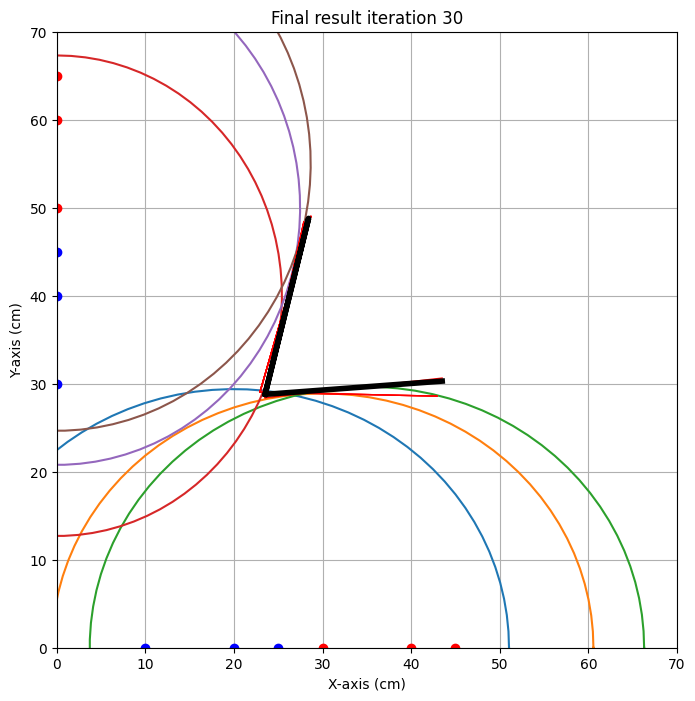

{'alpha': np.float64(4.300916794348771), 'alpha_eps': np.float64(5.59187522865173), 'beta': np.float64(13.79926576589095), 'beta_eps': np.float64(2.241685659269983), 'x0': np.float64(23.502796418018786), 'x0_eps': np.float64(0.5790441177559842), 'y0': np.float64(28.792026260292186), 'y0_eps': np.float64(0.38588086372782726)}
locatie 1 
x0 target is : 31.0. Gevonden waarde: 35.6 cm met een standaardafwijking van 2.3 cm 
y0 target is : 45.5. Gevonden waarde: 46.5 cm met een standaardafwijking van 2.6 cm 
alpha target is : 15.0. Gevonden waarde: 12.9 graden met een standaardafwijking van 14.3 graad 
beta target is : -20.0. Gevonden waarde: -14.5 graden met een standaardafwijking van 9.7 graad 

locatie 2 
x0 target is : 22.0. Gevonden waarde: 23.5 cm met een standaardafwijking van 0.6 cm 
y0 target is : 25.5. Gevonden waarde: 28.8 cm met een standaardafwijking van 0.4 cm 
alpha target is : 3.0. Gevonden waarde: 4.3 graden met een standaardafwijking van 5.6 graad 
beta target is : 27.0. Ge

In [10]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':31,#zelf aanvullen,
                    'y0':45.5,#zelf aanvullen,
                    'alpha':15, #zelf aanvullen,
                    'beta':-20 #zelf aanvullen},
            },
           'locatie 2':{'x0':22,#zelf aanvullen,
                    'y0':25.5,#zelf aanvullen,
                    'alpha':3,#zelf aanvullen,
                    'beta':27#zelf aanvullen}
            }}
           
Meting1 = np.array([98.10,98.62,101.27,74.68,68.28,67.41])
Meting2 = np.array([62.09,61.15,62.60,54.61,58.45,60.70])
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        #[0,30,0,10,Meting1[0]], # fout
        [50,0,30,0,Meting1[0]],
        [60,0,40,0,Meting1[1]],
        [65,0,45,0,Meting1[2]],
        #[30,0,10,0,Meting1[0]], # fout
        [0,50,0,30,Meting1[3]],
        [0,60,0,40,Meting1[4]],
        [0,65,0,45,Meting1[5]]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [30,0,10,0,Meting2[0]],
        [40,0,20,0,Meting2[1]],
        #[25,0,5,0,Meting2[2]], # fout
        [45,0,25,0,Meting2[2]],
        #[0,30,0,10,Meting2[3]], # fout
        [0,50,0,30,Meting2[3]],
        [0,60,0,40,Meting2[4]],
        [0,65,0,45,Meting2[5]]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  10   0  90.03
1  40   0  20   0  86.36
2  45   0  25   0  84.88
3  35   0  15   0  88.15
4   0  50   0  30  60.60
5   0  55   0  35  60.23
6   0  60   0  40  59.50
7   0  65   0  45  57.23


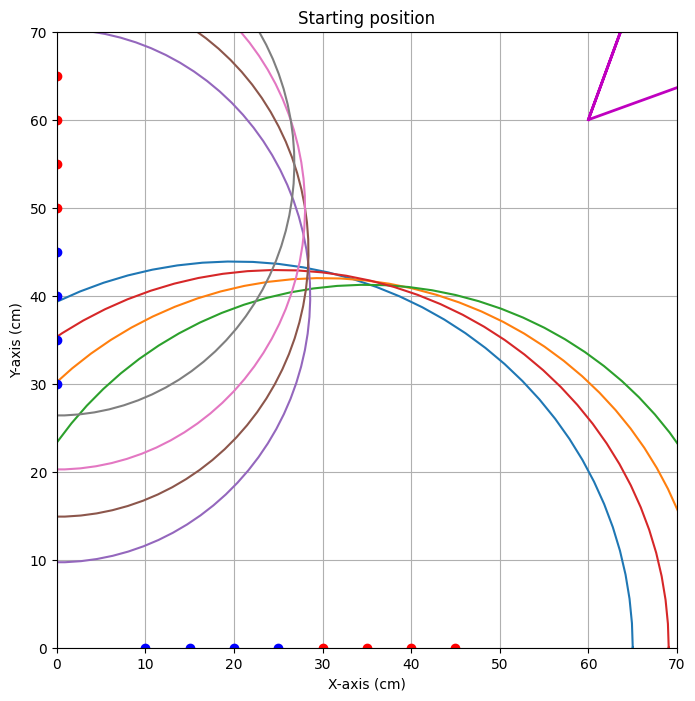


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.939


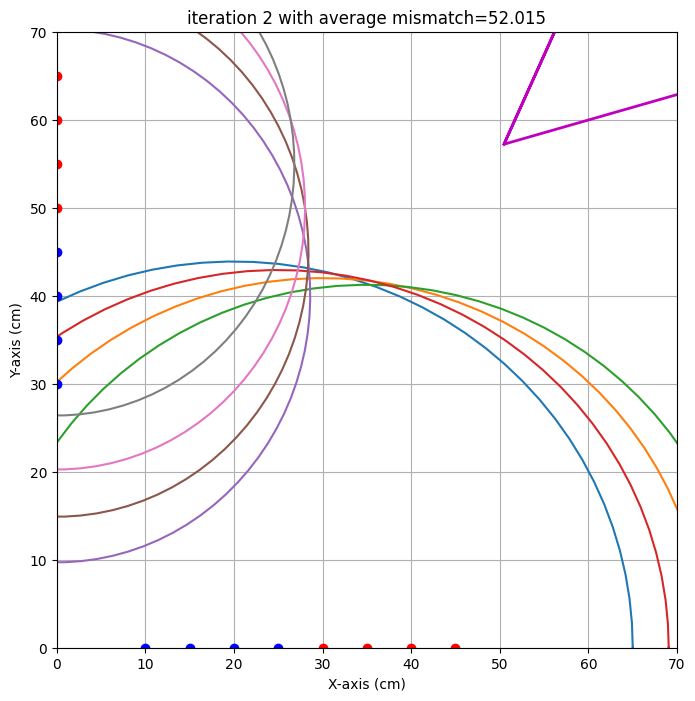

end iteration 2 with average mismatch=52.015


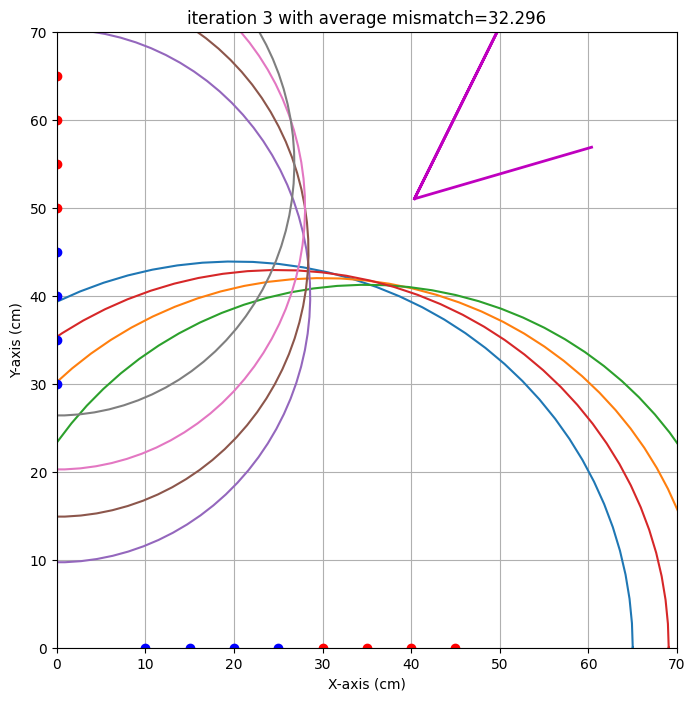

end iteration 3 with average mismatch=32.296


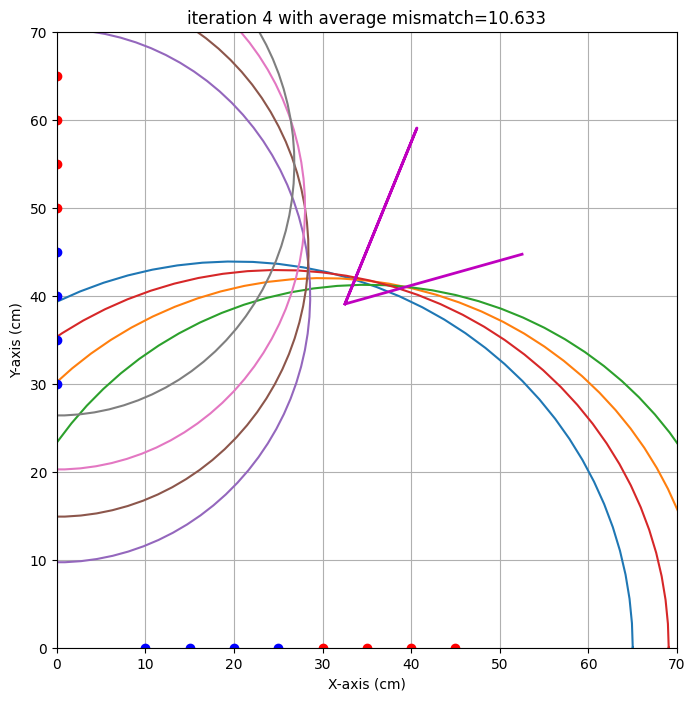

end iteration 4 with average mismatch=10.633


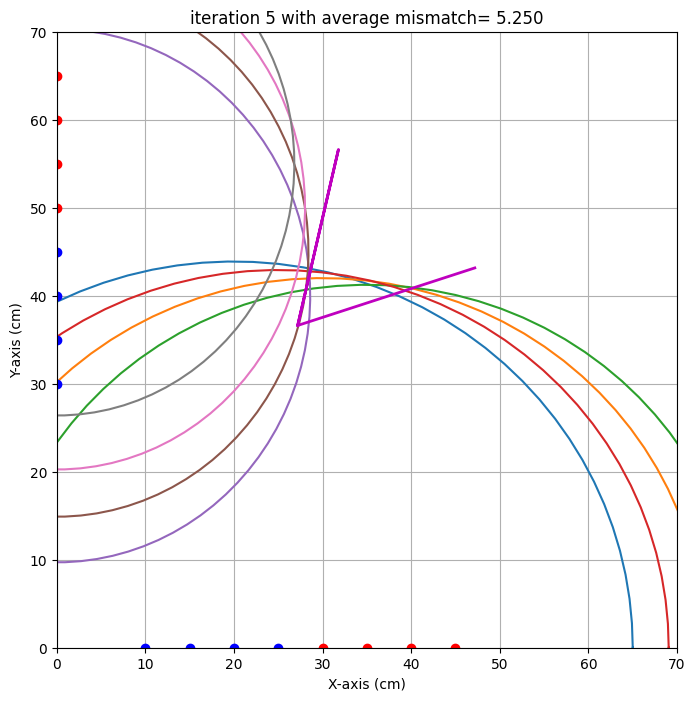

end iteration 5 with average mismatch= 5.250


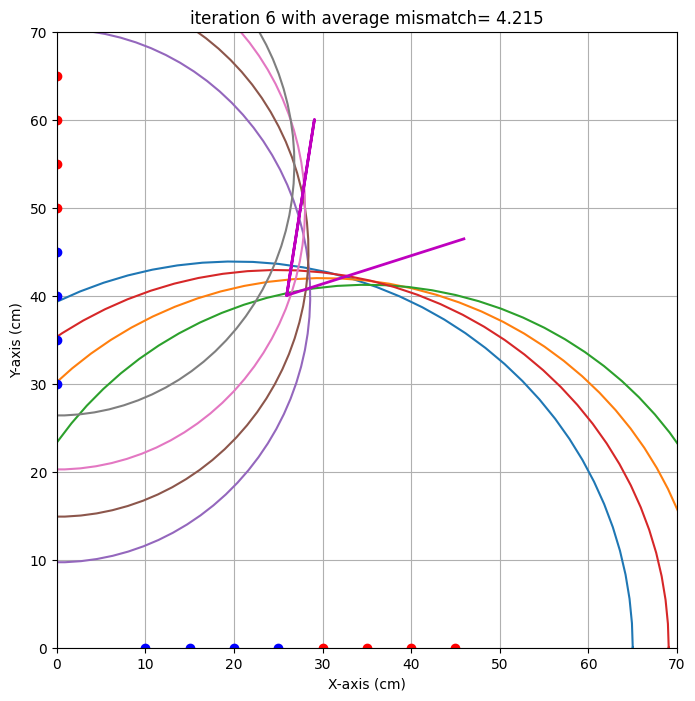

end iteration 6 with average mismatch= 4.215


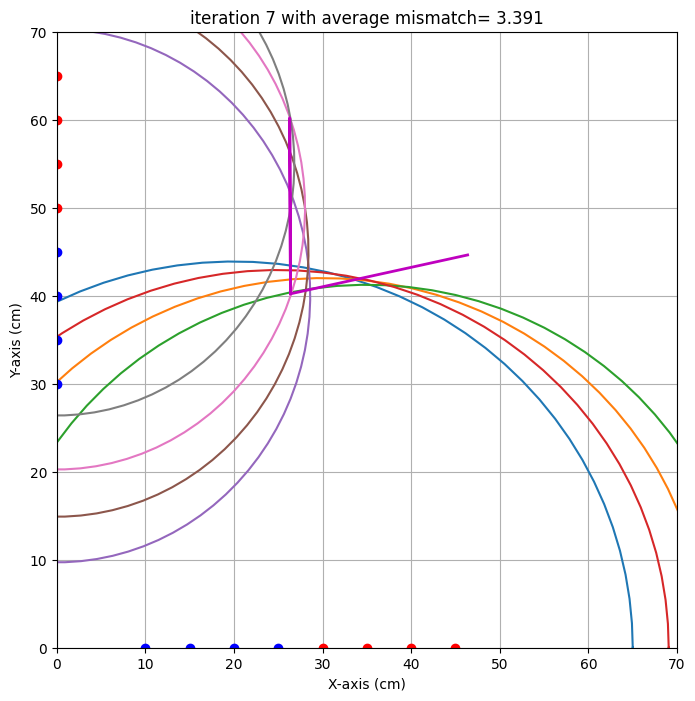

end iteration 7 with average mismatch= 3.391


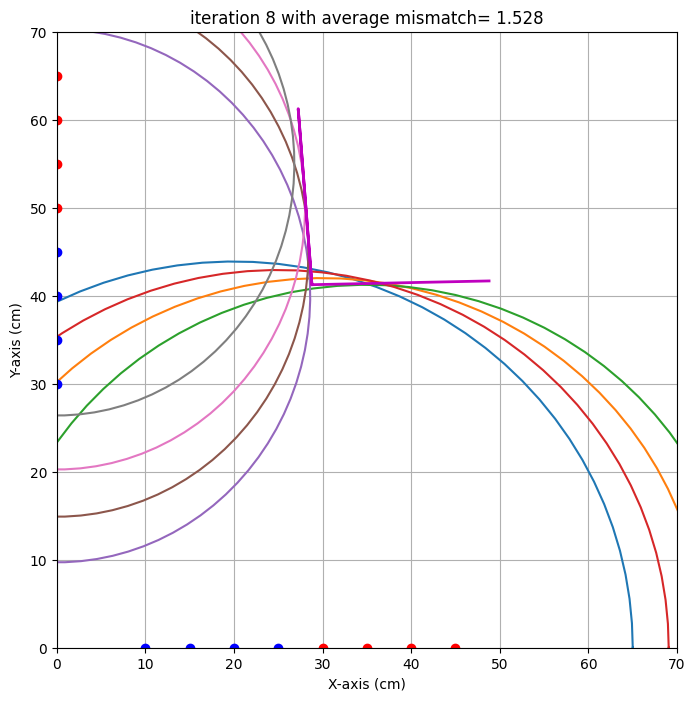

end iteration 8 with average mismatch= 1.528


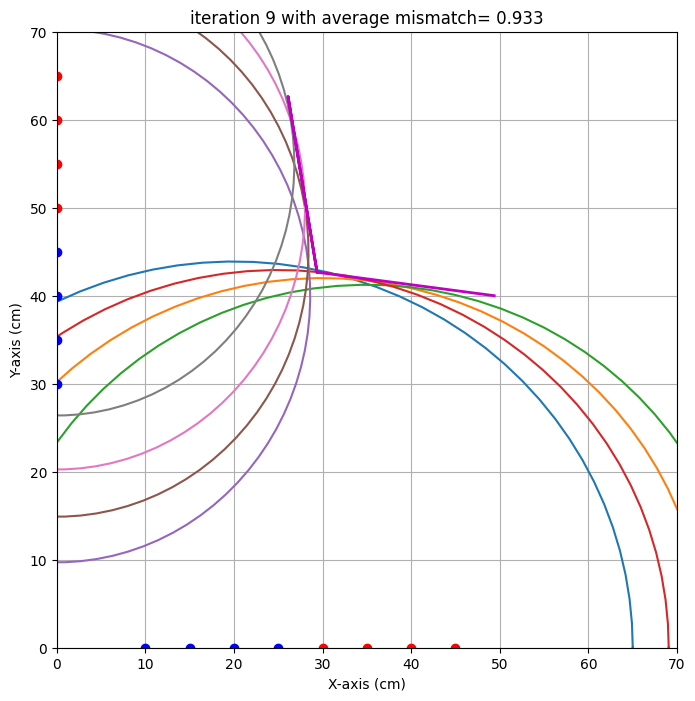

end iteration 9 with average mismatch= 0.933


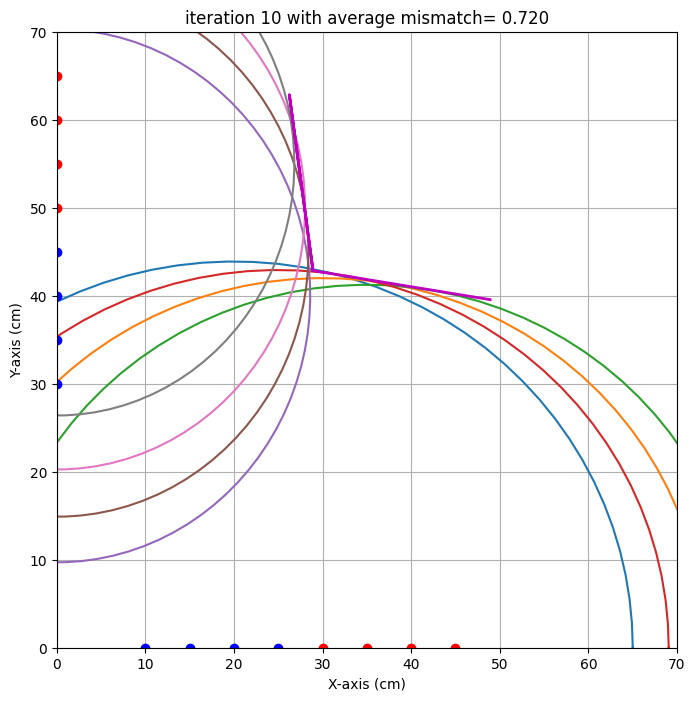

end iteration 10 with average mismatch= 0.720


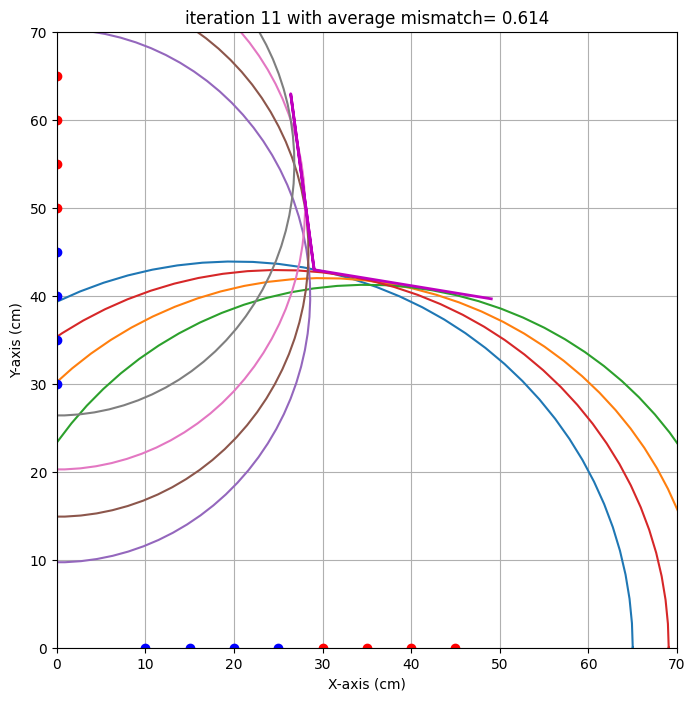

end iteration 11 with average mismatch= 0.614
end iteration 12 with average mismatch= 0.599
end iteration 13 with average mismatch= 0.598
end iteration 14 with average mismatch= 0.597
end iteration 15 with average mismatch= 0.597
end iteration 16 with average mismatch= 0.586
end iteration 17 with average mismatch= 0.576
end iteration 18 with average mismatch= 0.576
end iteration 19 with average mismatch= 0.576
end iteration 20 with average mismatch= 0.545
end iteration 21 with average mismatch= 0.540


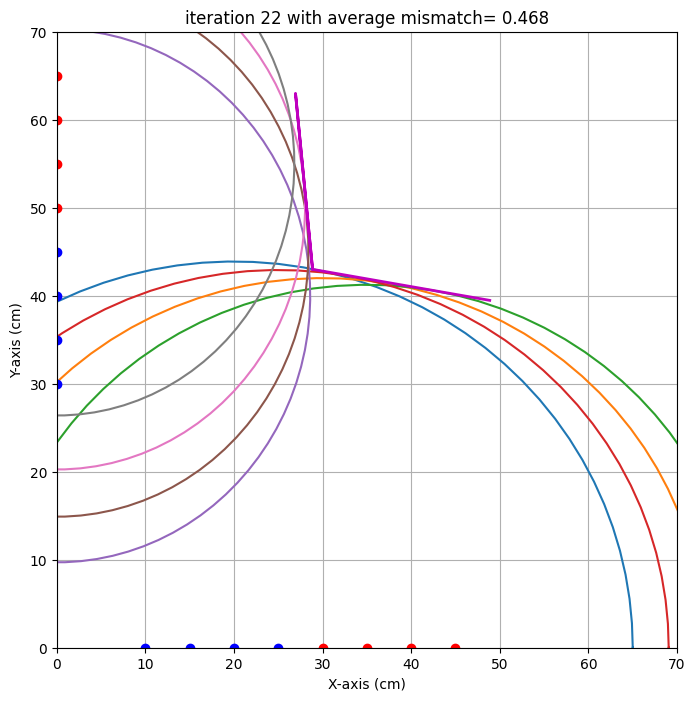

end iteration 22 with average mismatch= 0.468
end iteration 23 with average mismatch= 0.466
end iteration 24 with average mismatch= 0.466
end iteration 25 with average mismatch= 0.466
end iteration 26 with average mismatch= 0.466
end iteration 27 with average mismatch= 0.466
end iteration 28 with average mismatch= 0.466
end iteration 29 with average mismatch= 0.466
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.466
###############################################################################
end of iteration  30
Best alpha=  -9.99 with uncertainty=   2.25
Best beta =  -5.51 with uncertainty=   3.76
Best x0   =  28.87 with uncertainty=   0.61
Best y0   =  43.00 with uncertainty=   0.11
###############################################################################


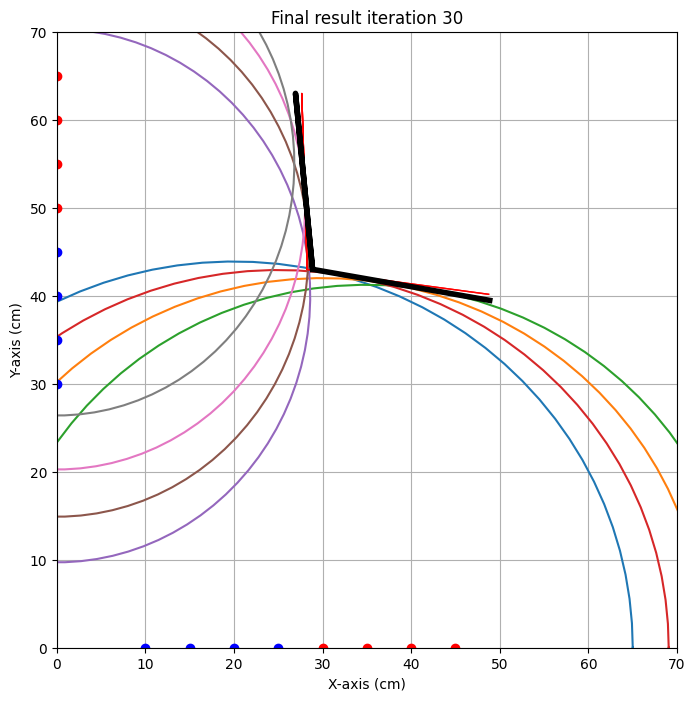

{'alpha': np.float64(-9.994466089272656), 'alpha_eps': np.float64(2.250454489333073), 'beta': np.float64(-5.512747676822439), 'beta_eps': np.float64(3.7597952198661595), 'x0': np.float64(28.865820385827217), 'x0_eps': np.float64(0.607054024127514), 'y0': np.float64(42.99516084071197), 'y0_eps': np.float64(0.11392315571911382)}
test locatie 
x0 target is : 28.0. Gevonden waarde: 28.9 cm met een standaardafwijking van 0.6 cm 
y0 target is : 42.0. Gevonden waarde: 43.0 cm met een standaardafwijking van 0.1 cm 
alpha target is : -10.0. Gevonden waarde: -10.0 graden met een standaardafwijking van 2.3 graad 
beta target is : -8.0. Gevonden waarde: -5.5 graden met een standaardafwijking van 3.8 graad 



In [11]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':28.0,  # zelf aanvullen,
                    'y0':42.0,  # zelf aanvullen,
                    'alpha':-10,  # zelf aanvullen,
                    'beta':-8  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.
Finalmeting = np.array([90.03,86.36,84.88,88.15,60.60,60.23,59.50,57.23])

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [30,0,10,0,Finalmeting[0]],
                    [40,0,20,0,Finalmeting[1]],
                    [45,0,25,0,Finalmeting[2]],
                    [35,0,15,0,Finalmeting[3]], 
                    #[0,30,0,10,Finalmeting[4]], # fout
                    [0,50,0,30,Finalmeting[4]], 
                    [0,55,0,35,Finalmeting[5]],
                    [0,60,0,40,Finalmeting[6]],
                    [0,65,0,45,Finalmeting[7]]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
### blokkenschema 1: Sybren
Ik heb hier gebruik gemaakt van een algoritme wat aan de buitenkanten begint van het gebied en naar binnen werkt. Hierbij wordt er meer rond het punt gemeten als het object "gezien" wordt.
![Alt](Algoritme_Sybren.jpeg)
### blokkenschema 2: Alesja
Dit schema scant steeds op een plek of er een object is. Als dat er niet is, wordt de meting een stap van 10cm opzij uitgevoerd. Als het wel is gevonden, wordt er ook 10 cm opzij opnieuw gemeten. Dit wordt op beide assen gedaan
![Alt](Algoritme_Alesja.jpeg)
### blokkenschema 3: Daan
    Ik heb gebruik gemaakt van de grootte van het object, daarom begin ik bij 30cm en als er geen geldige meting is ga ik aan de andere kant van de as meeten omdat de kans super groot is dat daar het object zich bevindt vervolgens zoek ik in de buurt van de plek waar het object is gevonden. Dit is het principe van mijn algorithme.
Uiteindelijk is deze gekozen voor het experiment hierna
![Alt](Algoritme_Daan.jpeg)
### blokkenschema 4: Verbetering na eerste iteratie
Tijdens het proberen van de originele algoritmes en wat proberen van andere dingen kwamen we er achter dat meer ruimte tussen de Bron en de Ontvanger erg hielp. Dus hebben we deze verdubbelt. Voor de rest is er weinig veranderd behalve kleine aanpassingen om fouten weg te halen.
![Alt](Verbeterd_algoritme.jpeg)
### blokkenschema 5: A3
TA vroeg om een duidelijkere versie op A3, dit is dat.
![ALT](Verbeterd_algoritme_A3.jpeg)